# PUNCH Coronagraph — Tab 1 (Step 1) Notebook

**Purpose:** Run MEE2024 **GUI Tab 1 equivalent** on PUNCH L3 coronagraph data (centroid finding + plate solve).

**Based on:** `MEE2024_Notebook_Version.ipynb` (validated against GUI on sample data).

---

## What you're running

| Item | Value |
|------|--------|
| **Input** | `PUNCH_L3_CAM_20260219001600_v0j_MEE.fits` (MEE-ready; science array in PRIMARY) |
| **Plate scale** | ~81 arcsec/pixel (much coarser than MEE eclipse ~1.85″/px) |
| **Settings** | sensitive mode ON, sigma_thresh=10, min_area=2, **circle mask r<1000 px** (run 03) |
| **Output** | `Coronagraph Runs/punch_tab1_run03/` |

---

## Quick start (MacBook)

1. Open this notebook with the project `.venv` kernel.
2. Run **Setup** (imports + database init).
3. Run **Step 1** cells in order (config → validate → `do_stack()` → results → plots).
4. Check outputs in `Coronagraph Runs/punch_tab1/`.

**Steps 2–5** below are still the sample-data pipeline from the main notebook. Ignore them for now unless you extend to full coronagraph analysis later.

---

## Output layout (`Coronagraph Runs/`)

```
Coronagraph Runs/
  punch_tab1/          ← this notebook (first PUNCH Tab 1 run)
  punch_tab1_run02/    ← duplicate output_directory for parameter sweeps
  ...                  ← add subfolders per run as needed
```

Each run creates a timestamped `CENTROID_OUTPUT*` folder and `centroid_data*.zip` inside the output directory you set in the Step 1 config cell.

---

## Tuning Tab 1 (PUNCH)

**Run log:**

| Run | sigma_thresh | corona mask | Centroids | Plate solve |
|-----|--------------|-------------|-----------|-------------|
| 01 | 6 | blob mask (never fired) | 9255 | FAILED |
| 02 | 10 | blob mask (never fired) | 4824 | FAILED |
| 03 | 10 | **circle mask r<1000 px** | *pending* | *pending* |

**Key finding (before run 03):** MEE's saturation blob mask never activated on PUNCH — the Sun is a zero-hole, not a saturated blob — so `blob_radius_extra` / `centroid_gap_blob` did nothing. Run 03 replaces it with an explicit **circle mask** (see the "Circle mask" cell) that blanks the corona within `MASK_RADIUS_PX` of center.

| Setting | Current | If too many junk centroids | If almost none |
|---------|---------|---------------------------|----------------|
| `MASK_RADIUS_PX` | 1000 | Raise (1100–1200) | Lower (800–900) |
| `centroid_gaussian_thresh` | 10 | Raise to 12 | Lower to 6–8 |
| `min_area` | 2 | Try 3 | Keep at 2 |

Plate solve may struggle at 81″/px. Target: tens–low hundreds of clean centroids in the outer field.


---

## 🔧 Setup: Import Libraries and Initialize

First, we import all the necessary libraries and initialize the database.

**⏱️ Note:** The database initialization may take a few minutes the first time you run this notebook. Subsequent runs will be much faster.

**✅ What this cell does:**
- Imports all required Python packages
- Initializes the star catalog database (for plate solving)
- Sets up visualization tools

**💡 Tip:** Run this cell first, and only once per notebook session.

---

In [ ]:
# ============================================================================
# IMPORTS: Load all necessary libraries
# ============================================================================

# Standard library imports
import os
import sys
from pathlib import Path
import json
import zipfile

# Scientific computing
import numpy as np
import pandas as pd

# Astronomy libraries
from astropy.io import fits
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

# MEE2024 package imports
# These are the core functions that do the actual work
from mee2024 import stacker_implementation  # For Steps 1 & 3: image stacking
from mee2024 import distortion_fitter       # For Steps 2 & 4: distortion fitting
from mee2024 import eclipse_analysis         # For Step 5: deflection calculation
from mee2024 import MEE2024util              # Utility functions
from mee2024 import database_cache          # Star catalog database

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# ============================================================================
# INITIALIZE DATABASE: Prepare star catalog for plate solving
# ============================================================================
# This loads the star catalog database (one-time setup, may take a minute)
print("Initializing star catalog database...")
database_cache.prepare_triangles()
print("✅ Database ready!")

Initializing star catalog database...
preparing
✅ Database ready!


working on loading triangles
preloaded triangles
finished preparation work


---

## Step 1 — Find Centroids (PUNCH Coronagraph / Tab 1)

**What:** Load PUNCH image → mask Sun blob → find centroids → plate solve → save `centroid_data*.zip`.

**Configured for:** `PUNCH_L3_CAM_20260219001600_v0j_MEE.fits` → `Coronagraph Runs/punch_tab1/`

Edit the configuration cell below to change files, output folder, or detection settings.


In [9]:
# ============================================================================
# STEP 1 (GUI TAB 1) — Find centroids (PUNCH coronagraph)
# ============================================================================
# Pre-configured for PUNCH L3 Tab 1 run. Edit paths/settings here only.
# ============================================================================

from pathlib import Path

PROJECT_ROOT = Path("/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder")

# ----------------------------------------------------------------------------
# 1) Select your files (YOU EDIT)
# ----------------------------------------------------------------------------

# Single PUNCH science frame (MEE-ready FITS: science array in PRIMARY HDU)
zenith_light_files = [
    str(PROJECT_ROOT / "PUNCH_L3_CAM_20260219001600_v0j_MEE.fits"),
]

# No dark/flat calibration for PUNCH L3 quick test
zenith_dark_files = []
zenith_flat_files = []

# Output folder — timestamped CENTROID_OUTPUT* subfolders land here
output_directory = str(PROJECT_ROOT / "Coronagraph Runs" / "punch_tab1_run03")
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Circle mask radius (pixels from image center). Everything inside this radius
# is blanked out BEFORE centroid finding (see the next cell). This removes the
# bright corona ring that was generating thousands of false detections.
# Option A = 1000 px (corona faded to <2x sky). Shrink later once plate solve works.
MASK_RADIUS_PX = 1000
IMAGE_CENTER = (2048, 2048)  # PUNCH Sun position (row, col)

# ----------------------------------------------------------------------------
# 2) Tab 1 settings (PUNCH / eclipse-style)
# ----------------------------------------------------------------------------
# Run 02: tighter detection + wider Sun/corona mask.
# Run 01 (sigma=6, blob 200/100) gave 9255 centroids -> plate solve FAILED
# (mostly corona/noise blobs). Raise sigma_thresh, widen blob mask.

TAB1_SETTINGS = {
    'flag_display': True,
    'save_dark_flat': False,
    'float_fits': False,

    # Display only — how many centroids to mark on the output PNG
    'd': 200,

    # NOTE: MEE's saturation blob mask does NOT fire on PUNCH (data is in physical
    # radiance units, Sun is a zero-hole not a saturated blob). We mask the corona
    # ourselves with a circle mask in the next cell, so this is turned OFF.
    'delete_saturated_blob': False,
    'blob_saturation_level': 95,
    'blob_radius_extra': 350,
    'centroid_gap_blob': 175,

    # Sensitive stacking mode (eclipse-style) — STRICTER threshold for run 02
    'centroid_gaussian_subtract': True,
    'sensitive_mode_stack': True,
    'centroid_gaussian_thresh': 10.0,
    'min_area': 2,
    'sigma_subtract': 0.0,
    'background_subtraction_mode': 'annular',

    'remove_edgy_centroids': True,
}

# ----------------------------------------------------------------------------
# 3) Defaults you do NOT touch (internal)
# ----------------------------------------------------------------------------

TAB1_DO_NOT_TOUCH = {
    'm': 30,
    'n': 30,
    'pxl_tol': 10,
    'cutoff': 100,
    'img_edge_distance': 5,
    'rough_match_threshhold': 36,
    'sanity_check_centroids': True,
    'experimental_background_subtract': False,
    'workDir': '',
    'workDir2': '',
    '-DARK-': '',
    '-FLAT-': '',
    'database': '',
    'flag_debug': False,
    'flag_display2': False,
}

options = {
    **TAB1_DO_NOT_TOUCH,
    **TAB1_SETTINGS,
    'output_dir': output_directory,
}

print("Step 1 (PUNCH Tab 1) configuration loaded")
print(f"   Light files: {len(zenith_light_files)}")
print(f"   Dark files:  {len(zenith_dark_files)}")
print(f"   Flat files:  {len(zenith_flat_files)}")
print(f"   Output:      {output_directory}")
print(f"   blob={options['delete_saturated_blob']}, sigma_thresh={options['centroid_gaussian_thresh']}, min_area={options['min_area']}")


Step 1 (PUNCH Tab 1) configuration loaded
   Light files: 1
   Dark files:  0
   Flat files:  0
   Output:      /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03
   blob=False, sigma_thresh=10.0, min_area=2


---

### Circle mask (PUNCH corona removal)

MEE's built-in Sun mask does **not** work on PUNCH (the data is in physical radiance units and the Sun is a zero-valued hole, not a saturated blob). So we blank the corona ourselves here.

**What this cell does:**
1. Loads the PUNCH science FITS.
2. Sets every pixel **within `MASK_RADIUS_PX` of center** to a flat sky value (removes the corona ring *and* avoids a bright cliff edge).
3. Saves a masked copy and points `zenith_light_files` at it, so centroid finding only sees the clean outer field.

Adjust `MASK_RADIUS_PX` in the config cell above (currently **1000 px**, Option A).

In [10]:
# ============================================================================
# CIRCLE MASK — blank the corona within MASK_RADIUS_PX before centroid finding
# ============================================================================
import numpy as np
from astropy.io import fits

_src = Path(zenith_light_files[0])
with fits.open(_src) as _hdul:
    _img = _hdul[0].data.astype(np.float32)
    _hdr = _hdul[0].header.copy()

_cy, _cx = IMAGE_CENTER
_yy, _xx = np.mgrid[0:_img.shape[0], 0:_img.shape[1]]
_r = np.sqrt((_yy - _cy) ** 2 + (_xx - _cx) ** 2)
_inside = _r < MASK_RADIUS_PX

# Fill value = median of a thin annulus just outside the mask, so the boundary
# blends into the sky instead of creating a new bright/dark cliff edge.
_ring = (_r >= MASK_RADIUS_PX) & (_r < MASK_RADIUS_PX + 80) & np.isfinite(_img)
_fill = float(np.median(_img[_ring])) if _ring.any() else 0.0

_masked = _img.copy()
_masked[_inside] = _fill

# Save masked copy next to the notebook and repoint the pipeline at it
_masked_path = _src.with_name(_src.stem + f"_circmask{MASK_RADIUS_PX}.fits")
fits.writeto(_masked_path, _masked, _hdr, overwrite=True)
zenith_light_files = [str(_masked_path)]

_n_masked = int(_inside.sum())
print(f"Circle mask applied: r < {MASK_RADIUS_PX} px around {IMAGE_CENTER}")
print(f"   Blanked {_n_masked:,} pixels ({100*_n_masked/_img.size:.1f}% of image) -> fill {_fill:.3e}")
print(f"   Masked FITS: {_masked_path.name}")
print(f"   Centroid finding will now use: {zenith_light_files[0]}")

Circle mask applied: r < 1000 px around (2048, 2048)
   Blanked 3,141,521 pixels (18.7% of image) -> fill 3.097e-13
   Masked FITS: PUNCH_L3_CAM_20260219001600_v0j_MEE_circmask1000.fits
   Centroid finding will now use: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/PUNCH_L3_CAM_20260219001600_v0j_MEE_circmask1000.fits


### Preview the pre-processed (circle-masked) image

Displays the masked frame the pipeline will actually use. The bright corona within `MASK_RADIUS_PX` is now flattened to sky level, leaving the clean outer field for centroid finding. A red circle marks the mask boundary.

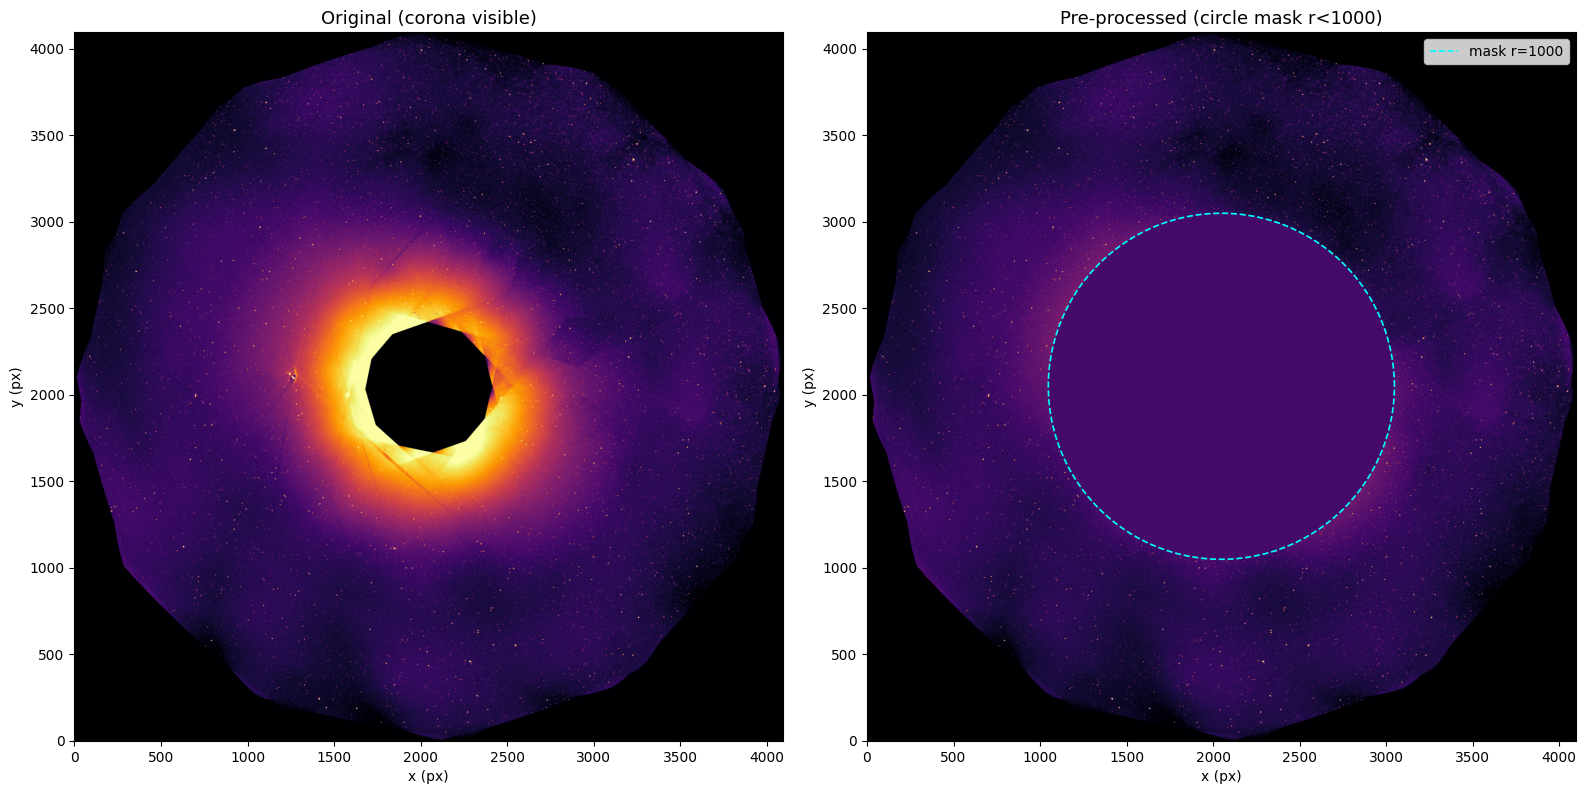

Saved preview -> /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/preprocessed_preview.png


In [11]:
# ============================================================================
# PREVIEW — pre-processed (circle-masked) image, next to the original
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval

_orig = fits.getdata(str(PROJECT_ROOT / "PUNCH_L3_CAM_20260219001600_v0j_MEE.fits")).astype(float)
_prep = fits.getdata(zenith_light_files[0]).astype(float)

# Shared asinh stretch based on the original's bright pixels
_norm = ImageNormalize(_orig, interval=PercentileInterval(99.0), stretch=AsinhStretch())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, data, title in [(axes[0], _orig, "Original (corona visible)"),
                        (axes[1], _prep, f"Pre-processed (circle mask r<{MASK_RADIUS_PX})")]:
    ax.imshow(data, origin="lower", cmap="inferno", norm=_norm)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")

# mask boundary circle on the pre-processed panel
_theta = np.linspace(0, 2*np.pi, 200)
axes[1].plot(IMAGE_CENTER[1] + MASK_RADIUS_PX*np.cos(_theta),
             IMAGE_CENTER[0] + MASK_RADIUS_PX*np.sin(_theta),
             color="cyan", lw=1.2, ls="--", label=f"mask r={MASK_RADIUS_PX}")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(Path(output_directory) / "preprocessed_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved preview -> {Path(output_directory) / 'preprocessed_preview.png'}")

### Validate Input Files

Before processing, let's check that all your input files exist and can be opened.

**✅ This validation step:**
- Checks that all file paths are correct
- Verifies files exist and can be read
- Reports any missing or invalid files
- Must pass before proceeding to processing

In [12]:
# ============================================================================
# FILE VALIDATION: Check that all input files exist and are readable
# ============================================================================
# Self-contained: imports os and defines validate_files inline so this cell
# works even if Setup wasn't run (re-running Step 1 config above is enough).
# ============================================================================

import os


def validate_files(file_list, file_type="light"):
    """
    Check if files exist and can be opened.
    
    Parameters:
    -----------
    file_list : list
        List of file paths to check
    file_type : str
        Type of files (for error messages): 'light', 'dark', or 'flat'
    
    Returns:
    --------
    valid_files : list
        List of valid file paths
    """
    valid_files = []
    for file_path in file_list:
        if not file_path:  # Skip empty strings
            continue
        if not os.path.exists(file_path):
            print(f"⚠️  WARNING: {file_type} file not found: {file_path}")
            continue
        try:
            # Try to open the file to verify it's readable
            with open(file_path, 'rb') as f:
                pass  # Just check if we can open it
            valid_files.append(file_path)
            print(f"✅ Valid {file_type} file: {os.path.basename(file_path)}")
        except Exception as e:
            print(f"❌ ERROR: Cannot open {file_type} file {file_path}: {e}")
    return valid_files

# ============================================================================
# VALIDATE ZENITH INPUT FILES
# ============================================================================

print("=" * 60)
print("VALIDATING ZENITH/NIGHTTIME INPUT FILES")
print("=" * 60)
print()

# Validate each type of file
valid_zenith_light_files = validate_files(zenith_light_files, "zenith light")
valid_zenith_dark_files = validate_files(zenith_dark_files, "zenith dark")
valid_zenith_flat_files = validate_files(zenith_flat_files, "zenith flat")

# Summary
print()
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"   Zenith light files: {len(valid_zenith_light_files)} valid out of {len(zenith_light_files)} specified")
print(f"   Zenith dark files:  {len(valid_zenith_dark_files)} valid out of {len(zenith_dark_files)} specified")
print(f"   Zenith flat files:  {len(valid_zenith_flat_files)} valid out of {len(zenith_flat_files)} specified")
print()

# Check if we have at least one light file (required!)
if len(valid_zenith_light_files) == 0:
    print("❌ ERROR: No valid zenith light files found!")
    print("   Please check your file paths in the Step 1 configuration cell above.")
    print("   Make sure to use absolute paths or paths relative to this notebook.")
    raise ValueError("No valid zenith light files provided. Cannot proceed without calibration images.")
else:
    print("✅ Validation complete! Ready to process zenith images.")
    print(f"   Processing {len(valid_zenith_light_files)} zenith light frame(s)...")

VALIDATING ZENITH/NIGHTTIME INPUT FILES

✅ Valid zenith light file: PUNCH_L3_CAM_20260219001600_v0j_MEE_circmask1000.fits

VALIDATION SUMMARY
   Zenith light files: 1 valid out of 1 specified
   Zenith dark files:  0 valid out of 0 specified
   Zenith flat files:  0 valid out of 0 specified

✅ Validation complete! Ready to process zenith images.
   Processing 1 zenith light frame(s)...


### Run Step 1: Stack Zenith Images and Find Centroids

Calls `stacker_implementation.do_stack()` — the same function as GUI Tab 1. May take several minutes.

STEP 1: STACKING ZENITH IMAGES AND FINDING CENTROIDS

Processing 1 zenith light frame(s)...

This may take several minutes depending on:
  - Number of images
  - Image size
  - Number of stars in the field

Starting processing...

logpath /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/CENTROID_OUTPUT20260703010432/LOG20260703010432.txt
using version:v0.6.0
using options:{'m': 30, 'n': 30, 'pxl_tol': 10, 'cutoff': 100, 'img_edge_distance': 5, 'rough_match_threshhold': 36, 'sanity_check_centroids': True, 'experimental_background_subtract': False, 'workDir': '', 'workDir2': '', '-DARK-': '', '-FLAT-': '', 'database': '', 'flag_debug': False, 'flag_display2': False, 'flag_display': True, 'save_dark_flat': False, 'float_fits': False, 'd': 200, 'delete_saturated_blob': False, 'blob_saturation_level': 95, 'blob_radius_extra': 350, 'centroid_gap_blob': 175, 'centroid_gaussian_subtract': True, 'sensitive_mode_stack': True, 'centroid_gaussian_t

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/mee2024/stacker_implementation.py:477: RuntimeWarning: invalid value encountered in sqrt
  data = np.maximum(sub / np.sqrt(local_variance) - options['sigma_subtract'], 0)
/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/mee2024/stacker_implementation.py:477: RuntimeWarning: invalid value encountered in divide
  data = np.maximum(sub / np.sqrt(local_variance) - options['sigma_subtract'], 0)


--- 10.746177196502686 seconds for centroid finding (prepare)---
--- 11.360559225082397 seconds for centroid finding (labelling)---
n centroids initial 4655
n centroids sanity-filtered 4650
--- 11.556161165237427 seconds for centroid finding (all)---
found: [(np.float64(6338.258521965758), np.float64(67.0), (np.float64(3358.3052931530656), np.float64(3231.2494209059905))), (np.float64(6077.923167917496), np.float64(40.0), (np.float64(2049.9252798924194), np.float64(3991.0790493379573))), (np.float64(5444.18599698879), np.float64(48.0), (np.float64(243.5166553832607), np.float64(1416.1621174042386))), (np.float64(4427.84214853883), np.float64(61.0), (np.float64(459.0400568990629), np.float64(2287.6296118048185))), (np.float64(4276.462093993565), np.float64(35.0), (np.float64(3798.97847678877), np.float64(2961.0373279813944))), (np.float64(4067.7379398514695), np.float64(33.0), (np.float64(1626.7892589955518), np.float64(671.639992658233))), (np.float64(3867.7698381964415), np.float64(34

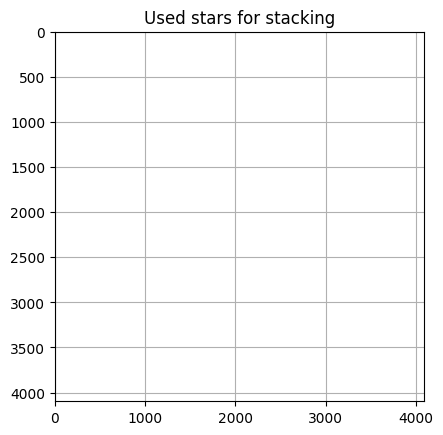

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/mee2024/stacker_implementation.py:719: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")


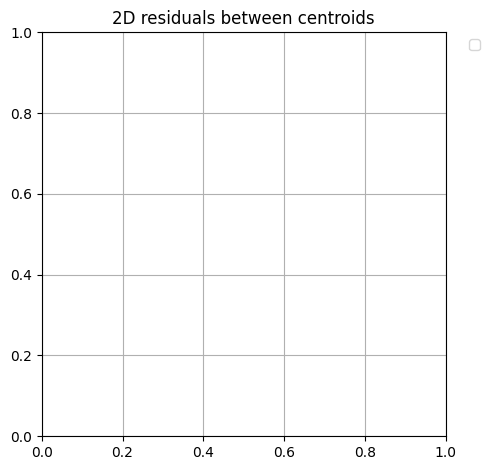

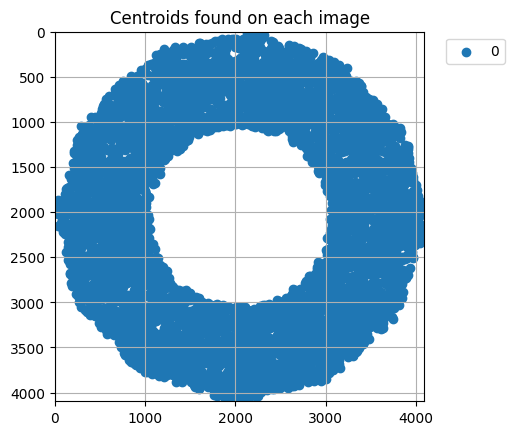

Stacking images...
  1/1


/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/mee2024/stacker_implementation.py:477: RuntimeWarning: invalid value encountered in sqrt
  data = np.maximum(sub / np.sqrt(local_variance) - options['sigma_subtract'], 0)
/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/mee2024/stacker_implementation.py:477: RuntimeWarning: invalid value encountered in divide
  data = np.maximum(sub / np.sqrt(local_variance) - options['sigma_subtract'], 0)


--- 10.00285792350769 seconds for centroid finding (prepare)---
--- 10.219254970550537 seconds for centroid finding (labelling)---
n centroids initial 4655
n centroids sanity-filtered 4650
--- 10.400748014450073 seconds for centroid finding (all)---
found: [(np.float64(6338.258521965758), np.float64(67.0), (np.float64(3358.3052931530656), np.float64(3231.2494209059905))), (np.float64(6077.923167917496), np.float64(40.0), (np.float64(2049.9252798924194), np.float64(3991.0790493379573))), (np.float64(5444.18599698879), np.float64(48.0), (np.float64(243.5166553832607), np.float64(1416.1621174042386))), (np.float64(4427.84214853883), np.float64(61.0), (np.float64(459.0400568990629), np.float64(2287.6296118048185))), (np.float64(4276.462093993565), np.float64(35.0), (np.float64(3798.97847678877), np.float64(2961.0373279813944))), (np.float64(4067.7379398514695), np.float64(33.0), (np.float64(1626.7892589955518), np.float64(671.639992658233))), (np.float64(3867.7698381964415), np.float64(34.

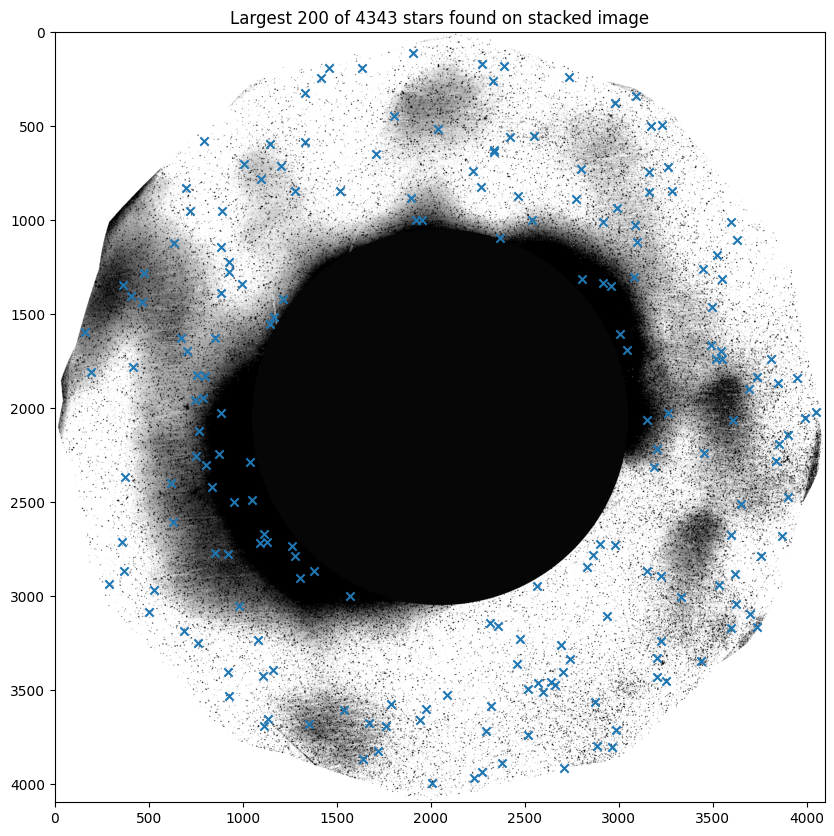

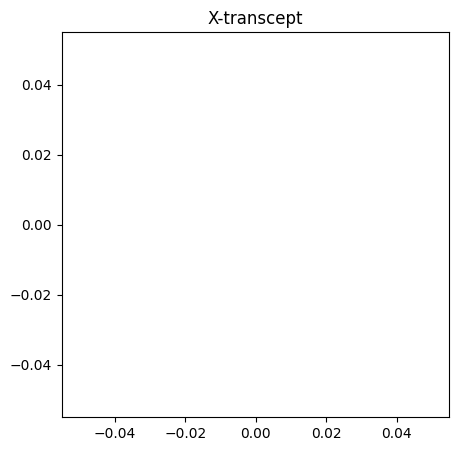

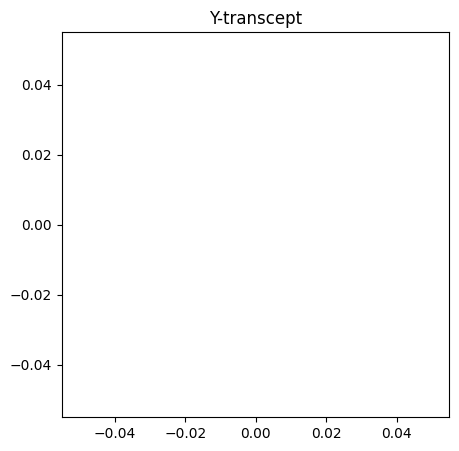

making archive /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/CENTROID_OUTPUT20260703010432 /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03
Done!

✅ SUCCESS! Zenith image stacking complete!

📁 Check your output directory for the results:
   Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03

   Look for files named:
   - centroid_data{timestamp}.zip  (main output file)
   - CENTROID_OUTPUT{timestamp}/    (output folder)

➡️  This ZIP file will be used as input for Step 2 (Zenith Distortion)


<Figure size 640x480 with 0 Axes>

In [13]:
# ============================================================================
# STEP 1: STACK IMAGES AND FIND STAR CENTROIDS
# ============================================================================
# 
# This function does the following:
#   1. Opens all your light images (and optional dark/flat frames)
#   2. Aligns them using star patterns (matches stars across frames)
#   3. Stacks them together (averages them) to reduce noise
#   4. Finds star positions (centroids) in the stacked image
#   5. Does "plate solving" - matches stars to catalog to find where you're pointing
#
# Function called: stacker_implementation.do_stack()
#   - This is the same function used by GUI Tab 1
#   - Takes: light files, dark files, flat files, options dictionary
#   - Returns: Nothing (saves output files directly)
#
# Output: A ZIP file containing:
#   - Star positions (centroids) in pixel coordinates
#   - Plate solution (RA, Dec, roll, plate scale in arcsec/pixel)
#   - Stacked image
#   - Log file with processing details
#
# This output file will be used as input for Step 2.
# ============================================================================

print("=" * 60)
print("STEP 1: STACKING ZENITH IMAGES AND FINDING CENTROIDS")
print("=" * 60)
print()
print(f"Processing {len(valid_zenith_light_files)} zenith light frame(s)...")
if valid_zenith_dark_files:
    print(f"Using {len(valid_zenith_dark_files)} dark frame(s) for noise reduction")
if valid_zenith_flat_files:
    print(f"Using {len(valid_zenith_flat_files)} flat frame(s) for vignetting correction")
print()
print("This may take several minutes depending on:")
print("  - Number of images")
print("  - Image size")
print("  - Number of stars in the field")
print()
print("Starting processing...")
print()

try:
    # Call the stacking function (same as GUI Tab 1)
    stacker_implementation.do_stack(
        valid_zenith_light_files,    # Zenith light images (required)
        valid_zenith_dark_files,     # Dark frames (optional)
        valid_zenith_flat_files,     # Flat frames (optional)
        options                      # All the settings from configuration
    )
    
    print()
    print("=" * 60)
    print("✅ SUCCESS! Zenith image stacking complete!")
    print("=" * 60)
    print()
    print("📁 Check your output directory for the results:")
    if output_directory:
        print(f"   Output directory: {output_directory}")
    else:
        print(f"   Output directory: {os.path.dirname(valid_zenith_light_files[0])}")
    print()
    print("   Look for files named:")
    print("   - centroid_data{timestamp}.zip  (main output file)")
    print("   - CENTROID_OUTPUT{timestamp}/    (output folder)")
    print()
    print("➡️  This ZIP file will be used as input for Step 2 (Zenith Distortion)")
    
except Exception as e:
    print()
    print("=" * 60)
    print("❌ ERROR during zenith stacking!")
    print("=" * 60)
    print(f"Error message: {e}")
    print()
    print("Common issues:")
    print("  - File paths incorrect (check Step 1 configuration cell)")
    print("  - Images corrupted or wrong format")
    print("  - Not enough stars in images for plate solving")
    print("  - Images too dark or too bright")
    print()
    raise

### Step 1 Results

Finds the output ZIP and saves its path as `step1_output_file` for Step 2.

In [6]:
# ============================================================================
# DISPLAY RESULTS: Show what was created
# ============================================================================
# This cell finds the output files created by Step 1 and displays information
# about them. The most recent output file will be used automatically in Step 2.
# ============================================================================

import glob
from pathlib import Path

# Determine output directory
if output_directory and os.path.isdir(output_directory):
    output_path = Path(output_directory)
else:
    # Use same directory as first input file
    output_path = Path(valid_zenith_light_files[0]).parent

print("=" * 60)
print("STEP 1 OUTPUT FILES")
print("=" * 60)
print()
print(f"Searching in: {output_path}")
print()

# Find centroid ZIP files (sorted by modification time, newest first)
centroid_zips = sorted(
    output_path.glob("centroid_data*.zip"), 
    key=lambda x: x.stat().st_mtime, 
    reverse=True
)

# Find output directories
output_dirs = sorted(
    output_path.glob("CENTROID_OUTPUT*"), 
    key=lambda x: x.stat().st_mtime if x.is_dir() else 0, 
    reverse=True
)

if centroid_zips:
    latest_zip = centroid_zips[0]
    print("✅ Found output files!")
    print()
    print(f"📦 Main output file (for Step 2):")
    print(f"   Name: {latest_zip.name}")
    print(f"   Full path: {latest_zip}")
    print(f"   Size: {latest_zip.stat().st_size / (1024*1024):.2f} MB")
    print()
    print("📝 This ZIP file contains:")
    print("   - Star positions (centroids) in pixel coordinates")
    print("   - Plate solution (RA, Dec, roll, plate scale)")
    print("   - Stacked image data")
    print("   - Processing log")
    print()
    
    # Store for use in Step 2
    step1_output_file = str(latest_zip)
    print(f"💾 Saved as 'step1_output_file' for use in Step 2")
    print()
    
    if output_dirs:
        print(f"📁 Output directory: {output_dirs[0].name}")
        print(f"   Contains plots, logs, and intermediate files")
        print()
    
    print("=" * 60)
    print("✅ Step 1 Complete! Ready for Step 2 (Zenith Distortion).")
    print("=" * 60)
    print()
    print("➡️  Next: Go to Step 2 (Zenith Distortion) section below")
    print("   The output file path will be used automatically")
    
else:
    print("⚠️  No output files found!")
    print()
    print("This could mean:")
    print("  - Processing is still running (check above for progress)")
    print("  - An error occurred (check error messages above)")
    print("  - Output directory is different than expected")
    print()
    print(f"   Searched in: {output_path}")
    print("   Looking for files matching: centroid_data*.zip")
    print()
    print("💡 Tip: If processing completed successfully, the output file")
    print("   should be in the same directory as your input images.")

STEP 1 OUTPUT FILES

Searching in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab1

✅ Found output files!

📦 Main output file (for Step 2):
   Name: centroid_data20260619130830.zip
   Full path: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab1/centroid_data20260619130830.zip
   Size: 0.35 MB

📝 This ZIP file contains:
   - Star positions (centroids) in pixel coordinates
   - Plate solution (RA, Dec, roll, plate scale)
   - Stacked image data
   - Processing log

💾 Saved as 'step1_output_file' for use in Step 2

📁 Output directory: CENTROID_OUTPUT20260619130830
   Contains plots, logs, and intermediate files

✅ Step 1 Complete! Ready for Step 2 (Zenith Distortion).

➡️  Next: Go to Step 2 (Zenith Distortion) section below
   The output file path will be used automatically


In [ ]:
# ============================================================================
# STEP 1 (Tab 1) — Display saved plots inline (no pop-ups)
# ============================================================================
# After Step 1 completes, it saves PNG plots inside the newest
# CENTROID_OUTPUT{timestamp}/ folder. This cell finds that folder and shows
# the key plots inline.

import os
from pathlib import Path

try:
    from IPython.display import display, Image
except Exception:
    display = None
    Image = None

# Find where Step 1 wrote outputs
if output_directory and os.path.isdir(output_directory):
    search_root = Path(output_directory)
else:
    search_root = Path(zenith_light_files[0]).parent

output_dirs = sorted(
    search_root.glob('CENTROID_OUTPUT*'),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if not output_dirs:
    print('No CENTROID_OUTPUT* folder found yet.')
    print(f'Searched in: {search_root}')
else:
    out = output_dirs[0]
    print(f'Using output folder: {out.name}')

    # Show the main plots in a consistent order
    plot_names = [
        'USEDSTARS',
        'TWOD_RESIDUALS',
        'CentroidsALL',
        'CentroidsStackGood',
    ]

    for stem in plot_names:
        matches = sorted(out.glob(f'{stem}*.png'), key=lambda p: p.stat().st_mtime, reverse=True)
        if not matches:
            print(f'  (missing) {stem}*.png')
            continue
        p = matches[0]
        print(f'  {p.name}')
        if display and Image:
            display(Image(filename=str(p)))

    # Results JSON (metadata) lives at out/data/results.txt
    results_path = out / 'data' / 'results.txt'
    if results_path.exists():
        print(f'\nresults.txt: {results_path}')
    else:
        print('\n(results.txt not found yet)')


---

# Gaia Matching — validate the centroids

**Goal:** Find out how many of the Tab 1 centroids are **real stars** vs junk, by comparing them to the **Gaia** catalog.

### The coordinate problem (why this needs SunPy)

PUNCH does **not** store positions in normal sky coordinates (RA/Dec). Its WCS is **helioprojective** — angles measured *from Sun center*, as seen from the spacecraft:

```
CTYPE1 = HPLN-ARC   CTYPE2 = HPLT-ARC   (helioprojective)
```

Gaia is in **ICRS** (RA/Dec). These are two different coordinate "languages." To compare them we need a translator that knows **where the spacecraft was** — and PUNCH's header has exactly that (`DSUN_OBS`, `DATE-OBS`, `CRLN_OBS`, `CRLT_OBS`). **SunPy** uses those keywords to convert between the two systems (same trick as `STEREO_SECCHI_starfield.ipynb`).

### Steps
1. Config (which run, match tolerance, magnitude limit)
2. Load PUNCH as a SunPy map (the translator)
3. Query Gaia for bright stars in the field
4. Move Gaia stars to the observation date, convert them to PUNCH pixels
5. Match centroids ↔ Gaia stars
6. Plots
7. Summary + save `PUNCH_GAIA_MATCHED.csv`

**Needs internet** (Gaia query), same as Steps 2 & 4.

In [14]:
# ============================================================================
# GAIA MATCH — 1) Config
# ============================================================================
import os, glob
from pathlib import Path

# --- Dials you can change ---
GAIA_MAG_LIMIT   = 8.0    # only include Gaia stars brighter than this (81"/px can't resolve faint ones)
MATCH_TOL_PIXELS = 2.0    # a centroid "matches" a Gaia star if within this many pixels (~162 arcsec)
SEARCH_MARGIN_DEG = 2.0   # extra padding added to the auto-computed Gaia cone-search radius

# --- Inputs ---
# PUNCH file used as the coordinate translator (needs full WCS + observer keywords).
# The _MEE copy has the science array + all keywords in PRIMARY and SunPy reads it as a
# single clean PUNCHMap (the original returns a [data, uncertainty] list).
PUNCH_WCS_FITS = str(PROJECT_ROOT / "PUNCH_L3_CAM_20260219001600_v0j_MEE.fits")

# Auto-find the newest run-03 centroid CSV (override CENTROID_CSV by hand if you want another run)
_run_root = PROJECT_ROOT / "Coronagraph Runs" / "punch_tab1_run03"
_csv_candidates = sorted(_run_root.glob("CENTROID_OUTPUT*/data/STACKED_CENTROIDS_DATA.csv"))
CENTROID_CSV = str(_csv_candidates[-1]) if _csv_candidates else None

# Where to save match outputs
GAIA_OUT_DIR = str(_run_root)

# Sun center pixel in the PUNCH image (CRPIX)
SUN_CENTER_PX = (2048.0, 2048.0)   # (x, y)

# SunPy needs a writable config dir; point it somewhere safe before importing sunpy
os.environ.setdefault("SUNPY_CONFIGDIR", os.path.expanduser("~/.sunpy"))

assert CENTROID_CSV is not None, f"No centroid CSV found under {_run_root}. Run Step 1 first."
print("Gaia-match config:")
print("  centroid CSV :", CENTROID_CSV)
print("  PUNCH WCS    :", PUNCH_WCS_FITS)
print("  mag limit    :", GAIA_MAG_LIMIT)
print("  match tol    :", MATCH_TOL_PIXELS, "px")
print("  output dir   :", GAIA_OUT_DIR)

Gaia-match config:
  centroid CSV : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/CENTROID_OUTPUT20260703010432/data/STACKED_CENTROIDS_DATA.csv
  PUNCH WCS    : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/PUNCH_L3_CAM_20260219001600_v0j_MEE.fits
  mag limit    : 8.0
  match tol    : 2.0 px
  output dir   : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03


In [15]:
# ============================================================================
# GAIA MATCH — 2) Load PUNCH as a SunPy map (the coordinate translator)
# ============================================================================
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, get_sun
import sunpy.map
import sunpy.coordinates  # registers Helioprojective <-> ICRS transforms

def _load_punch_map(path):
    """Load a PUNCH FITS as a single SunPy PUNCHMap.

    SunPy has a native PUNCH reader. The _MEE file returns one map; the original
    multi-HDU file returns a [data, uncertainty] list — take the first (data) map.
    """
    m = sunpy.map.Map(path)
    if isinstance(m, (list, tuple)):
        m = m[0]
    return m

punch_map = _load_punch_map(PUNCH_WCS_FITS)

print("SunPy map loaded")
print("  date        :", punch_map.date)
print("  frame       :", punch_map.coordinate_frame.name)
print("  shape       :", punch_map.data.shape)
try:
    print("  observer    :", punch_map.observer_coordinate)
except Exception as e:
    print("  observer    : (could not resolve:", e, ")")

# Gaia search center = the Sun's APPARENT sky position on the observation date.
# NOTE: we deliberately do NOT use pixel_to_world at the image center — the
# helioprojective origin sits at the Sun (distance ~0 from the barycenter), so its
# ICRS RA/Dec is numerically unstable/garbage. get_sun() gives the correct direction.
sun_icrs = get_sun(punch_map.date)
center_ra, center_dec = float(sun_icrs.ra.deg), float(sun_icrs.dec.deg)
print(f"  Sun apparent ICRS: RA={center_ra:.4f}  Dec={center_dec:.4f}")

# Cone-search radius from the plate scale: half the image diagonal + margin.
_scale = punch_map.scale  # Quantity per pixel, e.g. arcsec/pix
_cdelt_deg = float(_scale[0].to_value(u.deg / u.pix))
_ny, _nx = punch_map.data.shape
_half_diag_px = 0.5 * np.hypot(_nx, _ny)
SEARCH_RADIUS_DEG = _half_diag_px * _cdelt_deg + SEARCH_MARGIN_DEG
print(f"  plate scale: {_cdelt_deg*3600:.1f} arcsec/px  ->  Gaia cone radius: {SEARCH_RADIUS_DEG:.1f} deg")

SunPy map loaded
  date        : 2026-02-19T00:16:00.000
  frame       : helioprojective
  shape       : (4096, 4096)
  observer    : <SkyCoord (HeliographicStonyhurst: obstime=2026-02-19T00:12:29.166, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0., -6.97873671, 1.47879526e+11)>
  Sun apparent ICRS: RA=332.0757  Dec=-11.4755
  plate scale: 81.0 arcsec/px  ->  Gaia cone radius: 67.2 deg


In [16]:
# ============================================================================
# GAIA MATCH — 3) Query Gaia for bright stars in the field  (needs internet)
# ============================================================================
from astroquery.gaia import Gaia

_gaia_query = (
    "SELECT ra, dec, phot_g_mean_mag, parallax, pmra, pmdec, radial_velocity, ref_epoch "
    "FROM gaiadr3.gaia_source "
    f"WHERE phot_g_mean_mag < {GAIA_MAG_LIMIT} "
    f"AND CONTAINS(POINT('ICRS', ra, dec), "
    f"CIRCLE('ICRS', {center_ra}, {center_dec}, {SEARCH_RADIUS_DEG})) = 1"
)
print("Submitting Gaia query...")
gaia_job = Gaia.launch_job_async(_gaia_query)
gaia = gaia_job.get_results()
print(f"Gaia returned {len(gaia)} stars brighter than G={GAIA_MAG_LIMIT} within {SEARCH_RADIUS_DEG:.1f} deg")
gaia[:5].pprint(max_width=200)

Submitting Gaia query...
INFO: Query finished. [astroquery.utils.tap.core]
Gaia returned 18646 stars brighter than G=8.0 within 67.2 deg
        ra                dec         phot_g_mean_mag      parallax              pmra               pmdec        radial_velocity ref_epoch
       deg                deg               mag              mas               mas / yr            mas / yr           km / s         yr   
------------------ ------------------ --------------- ------------------ ------------------- ------------------- --------------- ---------
  9.74450912202209  44.66311639474568       7.8542495  4.396040655912204  36.684315663514056  -4.103462581360749              --    2016.0
10.361608835157778  44.81504632678321       7.3985434  4.361501611092189   81.70540187635235   62.49585205269133      -13.929735    2016.0
3.4039763499236444  47.19326175898451        7.941745 6.0576056843003405   -5.72556181323296 -1.4512028978713185     -0.17955461    2016.0
0.5523569443162653  49.771001

In [17]:
# ============================================================================
# GAIA MATCH — 4) Move stars to obs date, convert to PUNCH pixels, keep in-frame
# ============================================================================
from astropy.coordinates import Distance
from astropy.time import Time

def _col(name, fill=0.0):
    """Masked/NaN-safe float array from the Gaia table."""
    a = np.ma.getdata(gaia[name]).astype(float)
    m = np.ma.getmaskarray(gaia[name])
    a = np.where(m | ~np.isfinite(a), fill, a)
    return a

# Parallax -> distance. Floor to a tiny positive value so negative/zero parallaxes
# (which happen even for bright stars) become "effectively at infinity" instead of erroring.
_plx = _col('parallax', fill=1e-3)
_plx = np.where(_plx > 1e-3, _plx, 1e-3)   # mas
_dist = Distance(parallax=_plx * u.mas)

# Build SkyCoord with parallax + proper motion, then shift to the PUNCH observation date
_gaia_crds = SkyCoord(
    ra=_col('ra') * u.deg, dec=_col('dec') * u.deg,
    distance=_dist,
    pm_ra_cosdec=_col('pmra') * (u.mas / u.yr),
    pm_dec=_col('pmdec') * (u.mas / u.yr),
    radial_velocity=_col('radial_velocity') * (u.km / u.s),
    frame='icrs',
    obstime=Time(_col('ref_epoch', fill=2016.0), format='jyear'),
)
_gaia_now = _gaia_crds.apply_space_motion(new_obstime=punch_map.date)

# Convert to PUNCH pixel coordinates (SunPy transforms ICRS -> helioprojective -> pixel)
_gx, _gy = punch_map.world_to_pixel(_gaia_now)
gaia_px = np.asarray(_gx.value if hasattr(_gx, "value") else _gx, dtype=float)
gaia_py = np.asarray(_gy.value if hasattr(_gy, "value") else _gy, dtype=float)
gaia_mag = np.asarray(gaia['phot_g_mean_mag'], dtype=float)

# Keep only stars that land inside the 4096x4096 frame AND outside the circle mask
_ny, _nx = punch_map.data.shape
_r_from_sun = np.sqrt((gaia_px - SUN_CENTER_PX[0])**2 + (gaia_py - SUN_CENTER_PX[1])**2)
_in_frame = (gaia_px >= 0) & (gaia_px < _nx) & (gaia_py >= 0) & (gaia_py < _ny)
_outside_mask = _r_from_sun >= MASK_RADIUS_PX
_keep = _in_frame & _outside_mask

gaia_px, gaia_py, gaia_mag = gaia_px[_keep], gaia_py[_keep], gaia_mag[_keep]
print(f"Gaia stars total in query      : {len(_keep)}")
print(f"  ...inside image frame        : {int(_in_frame.sum())}")
print(f"  ...also outside r<{MASK_RADIUS_PX}px mask : {int(_keep.sum())}  <- usable truth set")

Gaia stars total in query      : 18646
  ...inside image frame        : 10376
  ...also outside r<1000px mask : 8560  <- usable truth set


/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 4 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [18]:
# ============================================================================
# GAIA MATCH — 5) Match centroids <-> Gaia stars
# ============================================================================
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Load Tab 1 centroids (pixel coords)
_cen_df = pd.read_csv(CENTROID_CSV)
cen_x = _cen_df['px'].to_numpy(dtype=float)   # px = column (x)
cen_y = _cen_df['py'].to_numpy(dtype=float)   # py = row (y)
cen_xy = np.c_[cen_x, cen_y]
gaia_xy = np.c_[gaia_px, gaia_py]

n_cen, n_gaia = len(cen_xy), len(gaia_xy)
print(f"Centroids: {n_cen}   Gaia truth stars in view: {n_gaia}")

if n_gaia == 0:
    raise RuntimeError("No Gaia stars landed in the usable field — check WCS/observer or magnitude limit.")

# For each centroid: nearest Gaia star
_nn_g = NearestNeighbors(n_neighbors=1).fit(gaia_xy)
d_c2g, i_c2g = _nn_g.kneighbors(cen_xy)
d_c2g, i_c2g = d_c2g[:, 0], i_c2g[:, 0]
centroid_matched = d_c2g < MATCH_TOL_PIXELS

# For each Gaia star: nearest centroid (did we detect it?)
_nn_c = NearestNeighbors(n_neighbors=1).fit(cen_xy)
d_g2c, i_g2c = _nn_c.kneighbors(gaia_xy)
d_g2c = d_g2c[:, 0]
gaia_detected = d_g2c < MATCH_TOL_PIXELS

n_matched   = int(centroid_matched.sum())
n_unmatched = n_cen - n_matched
n_detected  = int(gaia_detected.sum())
purity       = 100.0 * n_matched / n_cen   if n_cen  else 0.0
completeness = 100.0 * n_detected / n_gaia if n_gaia else 0.0

print(f"\nMatch tolerance: {MATCH_TOL_PIXELS} px (~{MATCH_TOL_PIXELS*81:.0f} arcsec)")
print(f"  Centroids matched to a Gaia star : {n_matched} / {n_cen}   (purity {purity:.1f}%)")
print(f"  Centroids with NO Gaia star      : {n_unmatched}   (likely junk)")
print(f"  Gaia stars we detected           : {n_detected} / {n_gaia}   (completeness {completeness:.1f}%)")

Centroids: 4343   Gaia truth stars in view: 8560

Match tolerance: 2.0 px (~162 arcsec)
  Centroids matched to a Gaia star : 3749 / 4343   (purity 86.3%)
  Centroids with NO Gaia star      : 594   (likely junk)
  Gaia stars we detected           : 3837 / 8560   (completeness 44.8%)


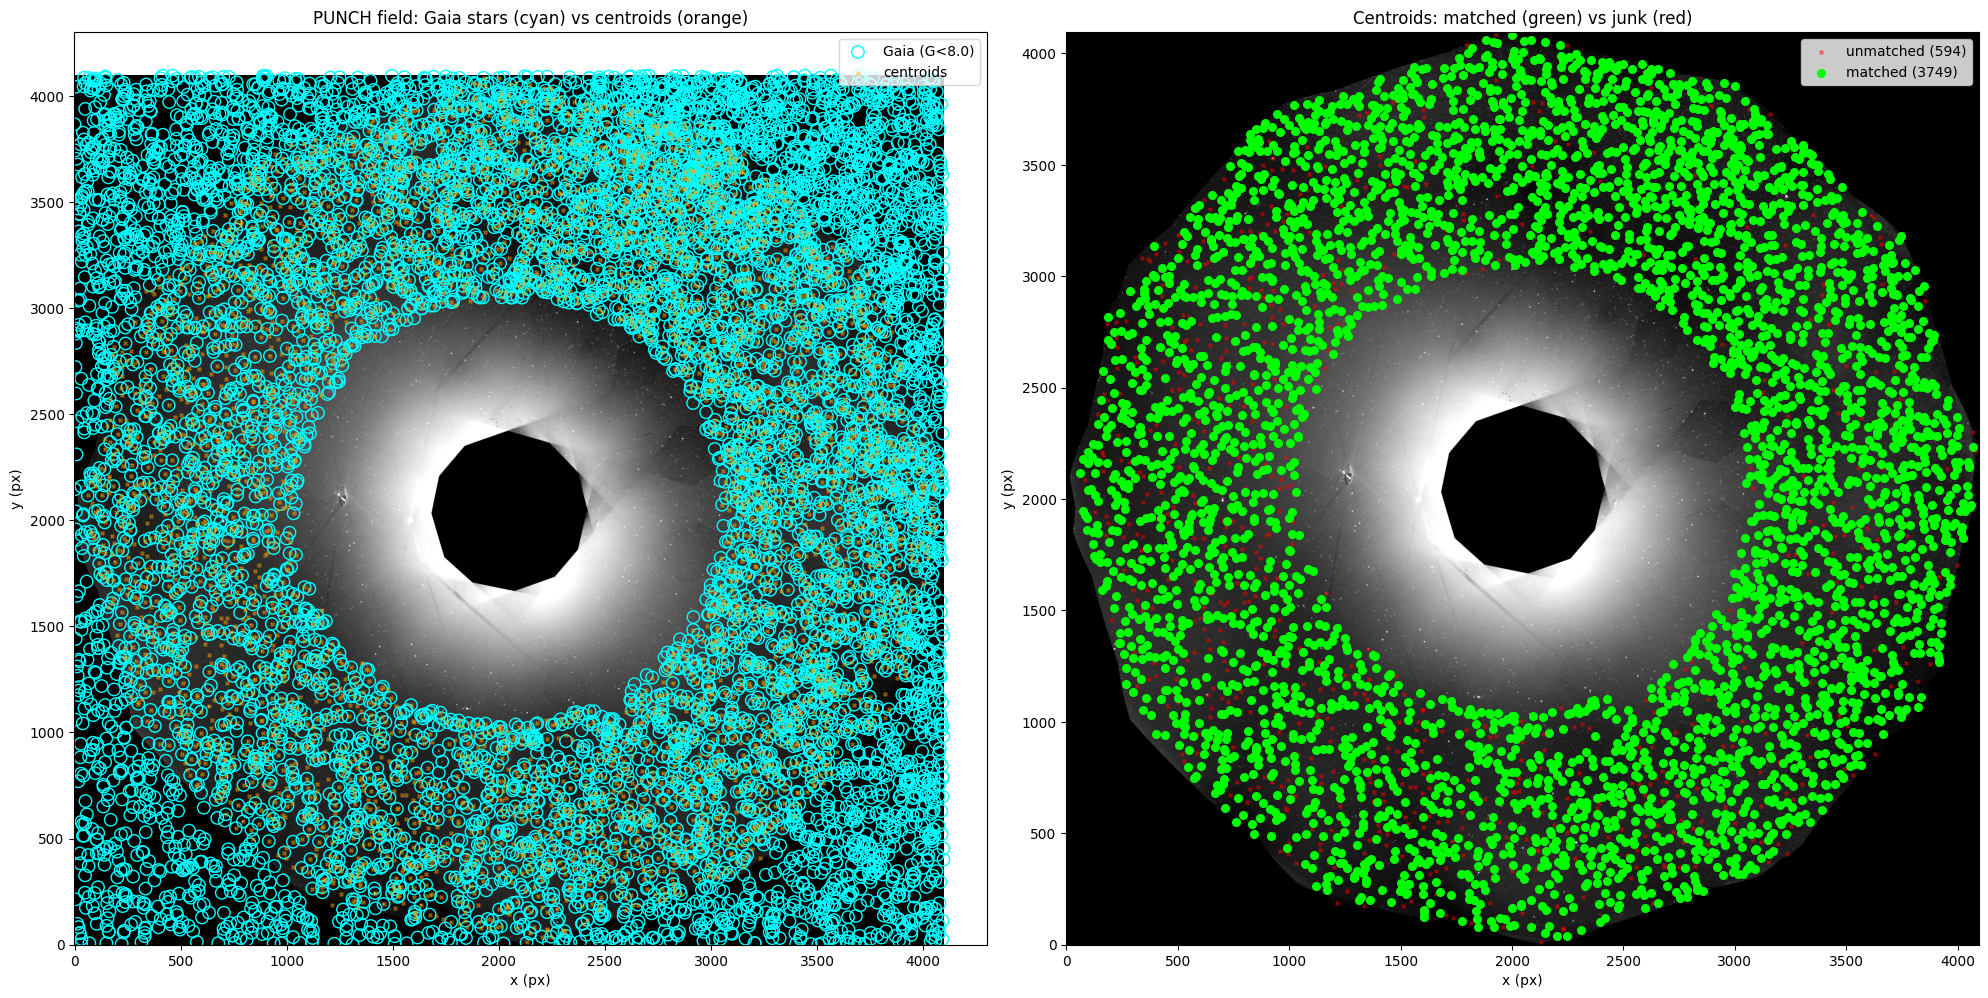

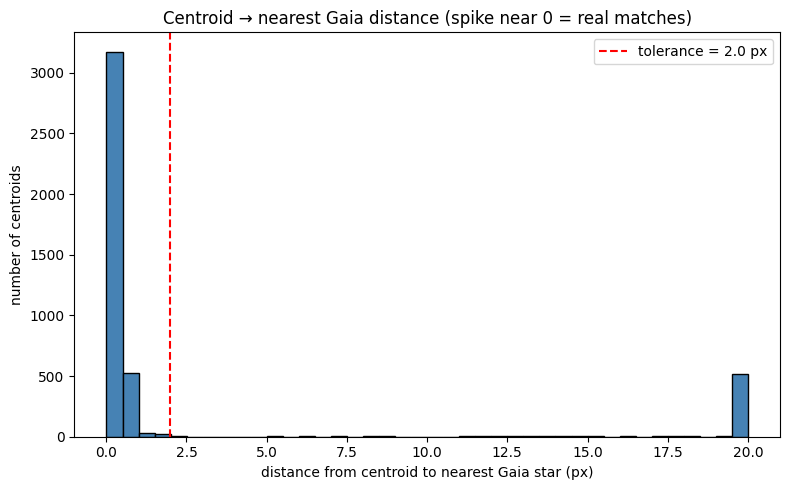

Saved plots to /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03


In [19]:
# ============================================================================
# GAIA MATCH — 6) Plots
# ============================================================================
import matplotlib.pyplot as plt
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval

_img = punch_map.data.astype(float)
_norm = ImageNormalize(_img, interval=PercentileInterval(99.0), stretch=AsinhStretch())

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# (a) Overlay: image + Gaia truth stars + our centroids
ax = axes[0]
ax.imshow(_img, origin="lower", cmap="gray", norm=_norm)
ax.scatter(gaia_px, gaia_py, s=80, facecolors="none", edgecolors="cyan",
           linewidths=1.0, label=f"Gaia (G<{GAIA_MAG_LIMIT})")
ax.scatter(cen_x, cen_y, s=6, c="orange", alpha=0.5, marker="x", label="centroids")
ax.set_title("PUNCH field: Gaia stars (cyan) vs centroids (orange)")
ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
ax.legend(loc="upper right")

# (b) Matched vs unmatched centroids
ax = axes[1]
ax.imshow(_img, origin="lower", cmap="gray", norm=_norm)
ax.scatter(cen_x[~centroid_matched], cen_y[~centroid_matched], s=6, c="red",
           alpha=0.5, marker="x", label=f"unmatched ({n_unmatched})")
ax.scatter(cen_x[centroid_matched], cen_y[centroid_matched], s=30, c="lime",
           marker="o", label=f"matched ({n_matched})")
ax.set_title("Centroids: matched (green) vs junk (red)")
ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(Path(GAIA_OUT_DIR) / "gaia_match_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# (c) Match-distance histogram
plt.figure(figsize=(8, 5))
plt.hist(np.clip(d_c2g, 0, 20), bins=40, color="steelblue", edgecolor="k")
plt.axvline(MATCH_TOL_PIXELS, color="red", ls="--", label=f"tolerance = {MATCH_TOL_PIXELS} px")
plt.xlabel("distance from centroid to nearest Gaia star (px)")
plt.ylabel("number of centroids")
plt.title("Centroid → nearest Gaia distance (spike near 0 = real matches)")
plt.legend()
plt.tight_layout()
plt.savefig(Path(GAIA_OUT_DIR) / "gaia_match_distance_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved plots to", GAIA_OUT_DIR)

In [20]:
# ============================================================================
# GAIA MATCH — 7) Summary table + save matched catalog
# ============================================================================
import pandas as pd

summary = pd.DataFrame({
    "metric": [
        "Gaia stars in usable field (mag<%.1f)" % GAIA_MAG_LIMIT,
        "Centroids total",
        "Centroids matched to Gaia (real)",
        "Centroids unmatched (likely junk)",
        "Gaia stars detected (completeness)",
        "Purity (matched / centroids)",
        "Completeness (detected / Gaia)",
        "Match tolerance (px)",
    ],
    "value": [
        n_gaia, n_cen, n_matched, n_unmatched, n_detected,
        f"{purity:.1f}%", f"{completeness:.1f}%", MATCH_TOL_PIXELS,
    ],
})
print(summary.to_string(index=False))

# Save the matched centroids with their Gaia identity (px, py, gaia px/py, mag, distance)
_matched_rows = pd.DataFrame({
    "centroid_px": cen_x[centroid_matched],
    "centroid_py": cen_y[centroid_matched],
    "gaia_px": gaia_px[i_c2g[centroid_matched]],
    "gaia_py": gaia_py[i_c2g[centroid_matched]],
    "gaia_G_mag": gaia_mag[i_c2g[centroid_matched]],
    "match_dist_px": d_c2g[centroid_matched],
})
_out_csv = Path(GAIA_OUT_DIR) / "PUNCH_GAIA_MATCHED.csv"
_matched_rows.to_csv(_out_csv, index=False)

_summary_csv = Path(GAIA_OUT_DIR) / "PUNCH_GAIA_MATCH_SUMMARY.csv"
summary.to_csv(_summary_csv, index=False)

print(f"\nSaved matched catalog -> {_out_csv}  ({len(_matched_rows)} rows)")
print(f"Saved summary         -> {_summary_csv}")

                              metric value
Gaia stars in usable field (mag<8.0)  8560
                     Centroids total  4343
    Centroids matched to Gaia (real)  3749
   Centroids unmatched (likely junk)   594
  Gaia stars detected (completeness)  3837
        Purity (matched / centroids) 86.3%
      Completeness (detected / Gaia) 44.8%
                Match tolerance (px)   2.0

Saved matched catalog -> /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/PUNCH_GAIA_MATCHED.csv  (3749 rows)
Saved summary         -> /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/PUNCH_GAIA_MATCH_SUMMARY.csv


---

# Deflection sensitivity check

**Goal:** See whether we can *detect* Einstein's light-bending signal in this PUNCH frame — not measure L accurately yet.

For each Gaia-matched star we compare:
- **Observed** position (centroid pixel → sky via WCS)
- **Catalog** position (Gaia pixel → sky)

Then plot the shift vs distance from the Sun, with Einstein's prediction `1.751″ / r` overlaid.

**This is a report card, not Tab 3.** If dots sit on the curve → signal is visible. If they're a noisy cloud far above the curve → we need closer stars and/or better positions before a real L fit makes sense.

In [21]:
# ============================================================================
# DEFLECTION SENSITIVITY — 1) Config + build star table
# ============================================================================
import os
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord
from astropy.io import fits
from pathlib import Path

os.environ.setdefault("SUNPY_CONFIGDIR", os.path.expanduser("~/.sunpy"))
import sunpy.map
import sunpy.coordinates
from sunpy.coordinates.screens import SphericalScreen
from mee2024.refraction_correction import _find_rotation_matrix

L_EINSTEIN = 1.751   # arcsec at 1 solar radius (Einstein prediction)

# Reuse Gaia-match outputs (auto-find if running this section alone)
_defl_root = Path(GAIA_OUT_DIR) if "GAIA_OUT_DIR" in globals() else Path(PROJECT_ROOT) / "Coronagraph Runs" / "punch_tab1_run03"
MATCHED_CSV = str(_defl_root / "PUNCH_GAIA_MATCHED.csv")
DEFL_OUT_DIR = str(_defl_root)

_wcs_fits = PUNCH_WCS_FITS if "PUNCH_WCS_FITS" in globals() else str(PROJECT_ROOT / "PUNCH_L3_CAM_20260219001600_v0j_MEE.fits")
_sun_cx, _sun_cy = (SUN_CENTER_PX if "SUN_CENTER_PX" in globals() else (2048.0, 2048.0))

# Load SunPy map (reload if Gaia cells weren't run this session)
if "punch_map" not in globals():
    _m = sunpy.map.Map(_wcs_fits)
    punch_map = _m[0] if isinstance(_m, (list, tuple)) else _m

# Solar radius from FITS header (arcsec) and plate scale (arcsec/pixel)
_hdr = fits.getheader(_wcs_fits, 0)
RSUN_ARC = float(_hdr.get("RSUN_ARC", 970.38))
_plate_arcsec = float(np.abs(punch_map.scale[0].to_value(u.arcsec / u.pix)))
RSUN_PX = RSUN_ARC / _plate_arcsec

def _as_unit_vector(dec_deg, ra_deg):
    dec = np.radians(dec_deg)
    ra = np.radians(ra_deg)
    return np.column_stack([np.cos(dec)*np.cos(ra), np.cos(dec)*np.sin(ra), np.sin(dec)])

def _px_to_radec(px, py):
    # Off-disk stars need SphericalScreen or pixel_to_world returns NaN
    with SphericalScreen(punch_map.observer_coordinate):
        w = punch_map.pixel_to_world(px * u.pix, py * u.pix).transform_to("icrs")
    return w.ra.deg, w.dec.deg

# Load matched pairs
_matched = pd.read_csv(MATCHED_CSV)
_ra_obs, _dec_obs = _px_to_radec(_matched["centroid_px"].values, _matched["centroid_py"].values)
_ra_cat, _dec_cat = _px_to_radec(_matched["gaia_px"].values, _matched["gaia_py"].values)

# Distance from Sun centre — use image-plane solar radii (helioprojective pixels / RSUN_PX).
# This matches the PUNCH field geometry; ICRS angular distance gives much larger r at these Tx,Ty.
_r_px = np.hypot(_matched["centroid_px"].values - _sun_cx, _matched["centroid_py"].values - _sun_cy)
_r_solar = _r_px / RSUN_PX

# Unit vectors on the sky (for rotation removal + radial deflection, Tab 3 style)
_sun = get_sun(punch_map.date)
_sun_v = _as_unit_vector(_sun.dec.deg, _sun.ra.deg)
_obs_v = _as_unit_vector(_dec_obs, _ra_obs)
_cat_v = _as_unit_vector(_dec_cat, _ra_cat)

# Angular distance obs ↔ catalog (total offset, arcsec)
_total_offset_arcsec = SkyCoord(ra=_ra_obs*u.deg, dec=_dec_obs*u.deg).separation(
    SkyCoord(ra=_ra_cat*u.deg, dec=_dec_cat*u.deg)
).arcsec

# Radial distance from Sun (catalog) on the celestial sphere
_rad_cat_rad = np.arcsin(np.linalg.norm(_cat_v - _sun_v, axis=1) / 2) * 2

# Bulk rotation removal, then radial deflection = change in Sun-distance (Tab 3 style)
_rot = _find_rotation_matrix(_obs_v, _cat_v)
_obs_rot = (_rot.T @ _obs_v.T).T
_rad_obs_rot_rad = np.arcsin(np.linalg.norm(_obs_rot - _sun_v, axis=1) / 2) * 2
_radial_deflection_arcsec = np.degrees(_rad_obs_rot_rad - _rad_cat_rad) * 3600.0

# Einstein prediction at each star's image-plane distance from the Sun
_einstein_pred_arcsec = L_EINSTEIN / _r_solar

# Noise floor from centroid↔Gaia match residuals
_noise_floor_arcsec = _matched["match_dist_px"].median() * _plate_arcsec

defl_df = pd.DataFrame({
    "centroid_px": _matched["centroid_px"],
    "centroid_py": _matched["centroid_py"],
    "RA_obs": _ra_obs,
    "DEC_obs": _dec_obs,
    "RA_catalog": _ra_cat,
    "DEC_catalog": _dec_cat,
    "magV": _matched["gaia_G_mag"],
    "r_px": _r_px,
    "r_solar": _r_solar,
    "total_offset_arcsec": _total_offset_arcsec,
    "radial_deflection_arcsec": _radial_deflection_arcsec,
    "einstein_pred_arcsec": _einstein_pred_arcsec,
    "residual_arcsec": _radial_deflection_arcsec - _einstein_pred_arcsec,
})

_out_table = Path(DEFL_OUT_DIR) / "PUNCH_DEFLECTION_CANDIDATES.csv"
defl_df.to_csv(_out_table, index=False)

print("Deflection sensitivity table built")
print(f"  stars          : {len(defl_df)}")
print(f"  plate scale    : {_plate_arcsec:.1f} arcsec/px")
print(f"  1 solar radius : {RSUN_PX:.1f} px  ({RSUN_ARC:.1f} arcsec)")
print(f"  r_solar range  : {defl_df.r_solar.min():.0f} – {defl_df.r_solar.max():.0f} R_sun")
print(f"  closest star   : Einstein pred = {defl_df.einstein_pred_arcsec.max():.4f} arcsec")
print(f"  noise floor    : ~{_noise_floor_arcsec:.1f} arcsec (median match residual)")
print(f"  saved          : {_out_table}")

Deflection sensitivity table built
  stars          : 3749
  plate scale    : 81.0 arcsec/px
  1 solar radius : 12.0 px  (970.4 arcsec)
  r_solar range  : 84 – 170 R_sun
  closest star   : Einstein pred = 0.0209 arcsec
  noise floor    : ~22.6 arcsec (median match residual)
  saved          : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/PUNCH_DEFLECTION_CANDIDATES.csv


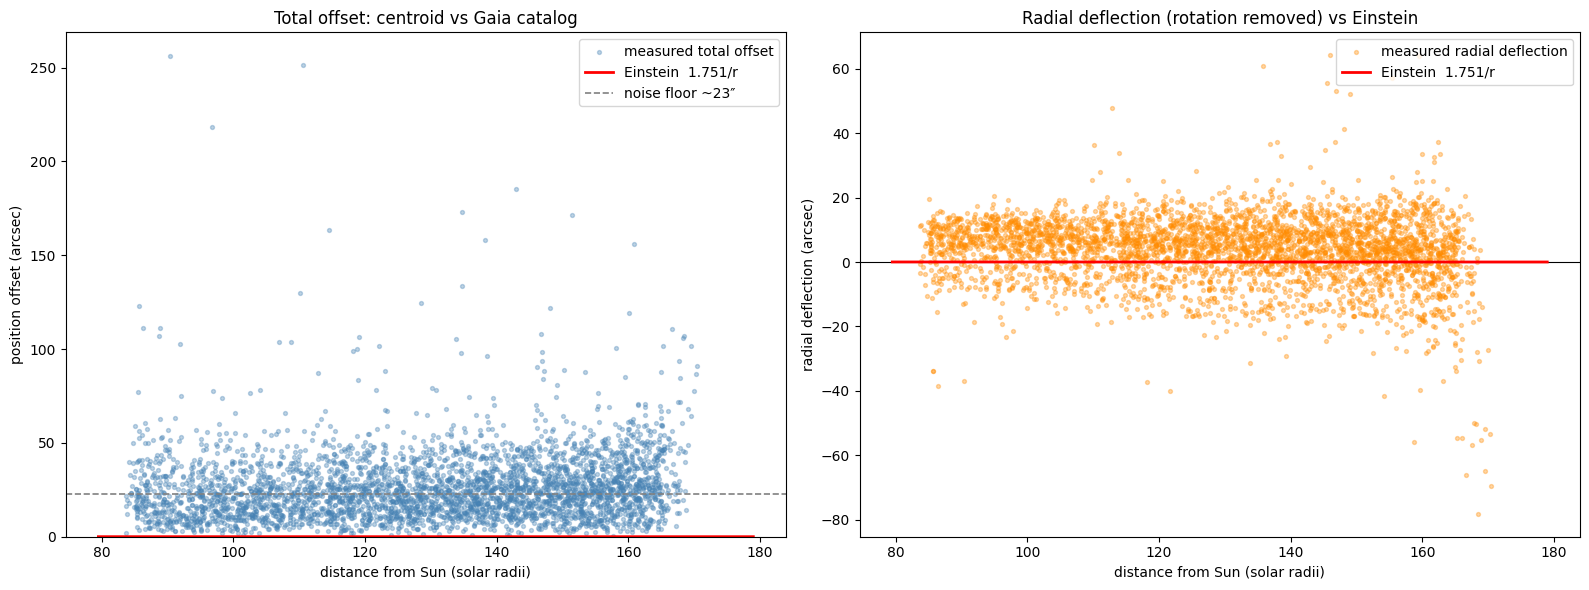

Saved -> /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab1_run03/deflection_sensitivity_scatter.png


In [22]:
# ============================================================================
# DEFLECTION SENSITIVITY — 2) Plots: total offset + radial deflection vs Einstein curve
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

_r = defl_df["r_solar"].values
_r_curve = np.linspace(max(1.0, _r.min() * 0.95), _r.max() * 1.05, 200)
_einstein_curve = L_EINSTEIN / _r_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Total angular offset obs − catalog
ax = axes[0]
ax.scatter(_r, defl_df["total_offset_arcsec"], s=8, alpha=0.35, c="steelblue", label="measured total offset")
ax.plot(_r_curve, _einstein_curve, "r-", lw=2, label=f"Einstein  {L_EINSTEIN}/r")
ax.axhline(_noise_floor_arcsec, color="gray", ls="--", lw=1.2, label=f"noise floor ~{_noise_floor_arcsec:.0f}″")
ax.set_xlabel("distance from Sun (solar radii)")
ax.set_ylabel("position offset (arcsec)")
ax.set_title("Total offset: centroid vs Gaia catalog")
ax.legend(loc="upper right")
ax.set_ylim(bottom=0)

# (b) Radial deflection after bulk rotation removal (Tab 3 style)
ax = axes[1]
ax.axhline(0, color="black", lw=0.8)
ax.scatter(_r, defl_df["radial_deflection_arcsec"], s=8, alpha=0.35, c="darkorange", label="measured radial deflection")
ax.plot(_r_curve, _einstein_curve, "r-", lw=2, label=f"Einstein  {L_EINSTEIN}/r")
ax.set_xlabel("distance from Sun (solar radii)")
ax.set_ylabel("radial deflection (arcsec)")
ax.set_title("Radial deflection (rotation removed) vs Einstein")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(Path(DEFL_OUT_DIR) / "deflection_sensitivity_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", Path(DEFL_OUT_DIR) / "deflection_sensitivity_scatter.png")

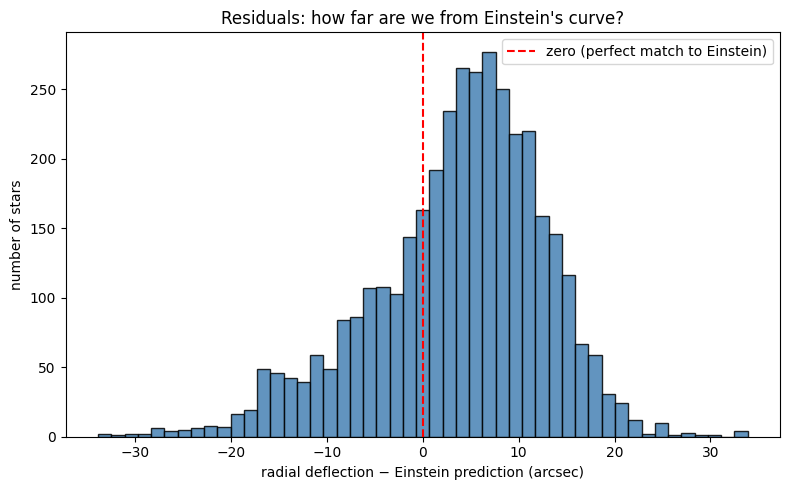

                                 metric                                                                                       value
                             Stars used                                                                                        3749
                   Closest star (R_sun)                                                                                        83.7
Einstein prediction at closest (arcsec)                                                                                      0.0209
           Median total offset (arcsec)                                                                                        23.2
    Median |radial deflection| (arcsec)                                                                                         7.4
 Median |residual vs Einstein| (arcsec)                                                                                         7.4
                   Noise floor (arcsec)                                     

In [23]:
# ============================================================================
# DEFLECTION SENSITIVITY — 3) Residual histogram + summary verdict
# ============================================================================
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Histogram: measured radial deflection − Einstein prediction
fig, ax = plt.subplots(figsize=(8, 5))
_residuals = defl_df["residual_arcsec"].values
_clip = np.percentile(np.abs(_residuals), 99)
_bins = np.linspace(-_clip, _clip, 50)
ax.hist(_residuals, bins=_bins, color="steelblue", edgecolor="k", alpha=0.85)
ax.axvline(0, color="red", ls="--", lw=1.5, label="zero (perfect match to Einstein)")
ax.set_xlabel("radial deflection − Einstein prediction (arcsec)")
ax.set_ylabel("number of stars")
ax.set_title("Residuals: how far are we from Einstein's curve?")
ax.legend()
plt.tight_layout()
plt.savefig(Path(DEFL_OUT_DIR) / "deflection_sensitivity_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
_closest_r = defl_df["r_solar"].min()
_pred_at_closest = L_EINSTEIN / _closest_r
_med_offset = defl_df["total_offset_arcsec"].median()
_med_radial = np.abs(defl_df["radial_deflection_arcsec"]).median()
_med_residual = np.abs(defl_df["residual_arcsec"]).median()
_snr = _pred_at_closest / _noise_floor_arcsec if _noise_floor_arcsec > 0 else 0.0

if _snr < 0.05:
    _verdict = "CANNOT measure L yet — signal << noise (stars too far from Sun and/or positions too coarse)"
elif _snr < 0.3:
    _verdict = "Signal barely visible — need closer stars and better astrometry before a real L fit"
else:
    _verdict = "Some sensitivity — a rough L fit might be attempted (expect large uncertainties)"

summary_rows = [
    ("Stars used", len(defl_df)),
    ("Closest star (R_sun)", f"{_closest_r:.1f}"),
    ("Einstein prediction at closest (arcsec)", f"{_pred_at_closest:.4f}"),
    ("Median total offset (arcsec)", f"{_med_offset:.1f}"),
    ("Median |radial deflection| (arcsec)", f"{_med_radial:.1f}"),
    ("Median |residual vs Einstein| (arcsec)", f"{_med_residual:.1f}"),
    ("Noise floor (arcsec)", f"{_noise_floor_arcsec:.1f}"),
    ("Signal / noise at closest star", f"{_snr:.4f}"),
    ("Verdict", _verdict),
]
summary_df = pd.DataFrame(summary_rows, columns=["metric", "value"])
print(summary_df.to_string(index=False))

_summary_path = Path(DEFL_OUT_DIR) / "PUNCH_DEFLECTION_SENSITIVITY_SUMMARY.txt"
with open(_summary_path, "w") as f:
    f.write("PUNCH Deflection Sensitivity Check\n")
    f.write("=" * 40 + "\n")
    for k, v in summary_rows:
        f.write(f"{k}: {v}\n")
print(f"\nSaved summary -> {_summary_path}")
print(f"Saved residuals plot -> {Path(DEFL_OUT_DIR) / 'deflection_sensitivity_residuals.png'}")

---

## 🔧 Step 2 — Compute Distortion (Zenith Calibration)

**What:** Match detected stars to the Gaia catalog and fit a polynomial distortion model for your telescope optics.

**Why:** Zenith images have many stars and no gravitational effects, so they give the best measurement of your telescope's intrinsic optical distortion (cubic, quintic terms). These higher-order coefficients will be frozen and reused in Step 4.

| | |
|---|---|
| **Inputs** | `centroid_data{timestamp}.zip` from Step 1 |
| **Outputs** | `distortion_data{timestamp}.zip` — distortion coefficients + matched star errors |
| **Feeds into** | Step 4 (as the reference distortion file) |
| **GUI equivalent** | Tab 2 (run on zenith data, `Fix order higher than` = None) |

**Key setting:** `distortion_fixed_coefficients = 'None'` — fit ALL polynomial orders (no freezing for zenith).

---

In [5]:
# ============================================================================
# STEP 2 (GUI TAB 2) — Compute distortion (Zenith calibration)
# ============================================================================
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# 1) FILES & FOLDERS  (top of Tab 2 window)
# ─────────────────────────────────────────────────────────────────────────────

# GUI: "File(s)" — centroid zip from Tab 1 / Step 1
# Validated notebook Step 1 output (CSVs byte-identical to Final SD GUI Tab 1
# centroid_data20260619125932.zip). Compare Step 2 output to:
# Final SD GUI Runs/06-19 Calibration Tab 2/distortion_data20260619134514…
zenith_centroid_zip = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/zenith_calibration_tab1/centroid_data20260619130830.zip"
)

# GUI: "Fix distortion file(s)" — blank for zenith (full fit from scratch)
distortion_reference_files = ""

# GUI: "Fix order higher than"
distortion_fixed_coefficients = "None"

# GUI: "Output folder (blank for same as input)"
step2_output_directory = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/zenith_calibration_tab2"
)

Path(step2_output_directory).mkdir(parents=True, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# 2) TAB 2 SETTINGS  (same order as GUI, top → bottom)
# ─────────────────────────────────────────────────────────────────────────────

TAB2_SETTINGS = {

    # --- Display ---
    # GUI: ☑ Show graphics
    "flag_display2": True,

    # --- Star catalog / matching ---
    # GUI: Maximum star magnitude
    "max_star_mag_dist": 12.0,

    # GUI: ☐ Guess Date!
    "guess_date": False,

    # GUI: Observation Date UTC (YYYY-MM-DD)
    "observation_date": "2024-04-08",

    # GUI: Distortion fit tolerance (arcsec)
    "distortion_fit_tol": 2.0,

    # GUI: Distortion polynomial order
    "distortionOrder": "quintic",

    # GUI: Rough fit threshold (arcsec)
    "rough_match_threshhold": 100.0,

    # GUI: ☐ Crop circle?  + threshold (0.0–1.0)
    "crop_circle": False,
    "crop_circle_thresh": 0.8,

    # GUI: ☑ Discard double-stars or stars with missing proper-motion
    "remove_double_tab2": True,

    # --- Corrections for aberration, parallax, and refraction ---
    # GUI: ☑ Enable aberration and parallax?
    "enable_corrections": True,

    # GUI: ☐ Enable gravitational correction?
    "enable_gravitational_def": False,

    # GUI: ☐ Simultaneous deflection constant and platescale fit
    "gravity_sweep": False,

    # GUI: Observation Time / Latitude / Longitude
    "observation_time": "06:10",
    "observation_lat": "23.8495",
    "observation_long": "-105.2728",

    # GUI: ☑ Enable refraction correction?
    "enable_corrections_ref": True,

    # GUI: (optional) atmosphere / site
    "observation_temp": 15.0,
    "observation_pressure": 760.0,
    "observation_humidity": 0.25,
    "observation_height": 2400.0,
    "observation_wavelength": 0.625,

    # --- Wired from paths above ---
    "distortion_reference_files": distortion_reference_files,
    "distortion_fixed_coefficients": distortion_fixed_coefficients,
}


# ─────────────────────────────────────────────────────────────────────────────
# 3) INTERNAL DEFAULTS  (not shown on Tab 2 GUI)
# ─────────────────────────────────────────────────────────────────────────────

TAB2_INTERNAL = {
    "catalogue": "gaia",
    "safety_limit_mag": 13,
    "double_star_cutoff": 10,
    "double_star_mag": 17,
    "DEFAULT_DATE": "2020-01-01",
    "basis_type": "polynomial",
    "workDir": "",
    "workDir2": "",
    "database": "",
    "flag_debug": False,
    "flag_display": False,
}

options = {**TAB2_INTERNAL, **TAB2_SETTINGS, "output_dir": step2_output_directory}
centroid_zip_path = zenith_centroid_zip
output_directory = step2_output_directory  # alias for run/results cells

print("✅ Step 2 (Tab 2) configuration loaded!")
print(f"   Input zip: {zenith_centroid_zip}")
print(f"   Output directory: {step2_output_directory}")


✅ Step 2 (Tab 2) configuration loaded!
   Input zip: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab1/centroid_data20260619130830.zip
   Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab2


### Run Step 2: Fit Zenith Distortion Model

Calls `distortion_fitter.match_and_fit_distortion()` — the same function as GUI Tab 2. Matches stars to Gaia and fits the full distortion model (all polynomial orders).

STEP 2: FITTING ZENITH DISTORTION MODEL

Input file: centroid_data20260619130830.zip
Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab2

This step will:
  1. Load star positions from Step 1
  2. Match stars to Gaia catalog (may take a few minutes)
  3. Fit distortion polynomial

Starting processing...

<ForkProcess name='ForkProcess-2' pid=43634 parent=43248 stopped exitcode=0> False
joined
loaded database
 Real time loading: 1.69 seconds
mean: [34.36157035 19.22488978]
 Real time prepare: 0.56 seconds
 Real time match: 0.16 seconds
 Real time platescale compute: 0.35 seconds
initial triangle matches: 718260
triangle match: 4 [(0, 9, 2), (0, 9, 3), (2, 3, 0), (2, 3, 9)]
note: candidate match rejected (nstars matched = 11, thresh = 39)
triangle match: 66 [(0, 3, 4), (0, 3, 5), (0, 3, 12), (0, 3, 17), (0, 4, 5), (0, 4, 12), (0, 17, 4), (0, 5, 12), (0, 17, 5), (0, 17, 12), (1, 8, 2), (1, 2, 9), (1, 10, 2), (1, 2, 13),

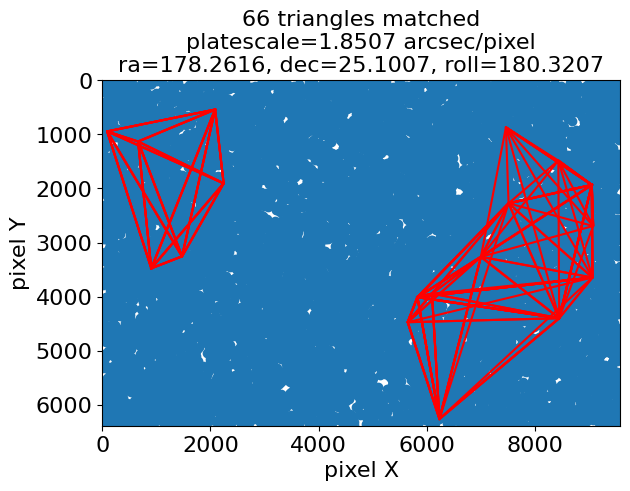

SELECT source_id, phot_g_mean_mag, COORD1(ESDC_EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2024.2833205563466)),COORD2(ESDC_EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2024.2833205563466)), parallax, pmra, pmdec, ref_epoch FROM gaiadr3.gaia_source WHERE ra BETWEEN 175.49578328506533 AND 181.00686452635884 AND dec BETWEEN 23.420635719040245 AND 26.730967448014294 AND phot_g_mean_mag BETWEEN 3 AND 12.0
INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 358
     SOURCE_ID      phot_g_mean_mag       COORD1             COORD2            parallax              pmra               pmdec        ref_epoch
                          mag                                                    mas               mas / yr            mas / yr          yr   
------------------- --------------- ------------------ ------------------ ------------------ ------------------- ------------------- ---------
4004213918619664896        9.582

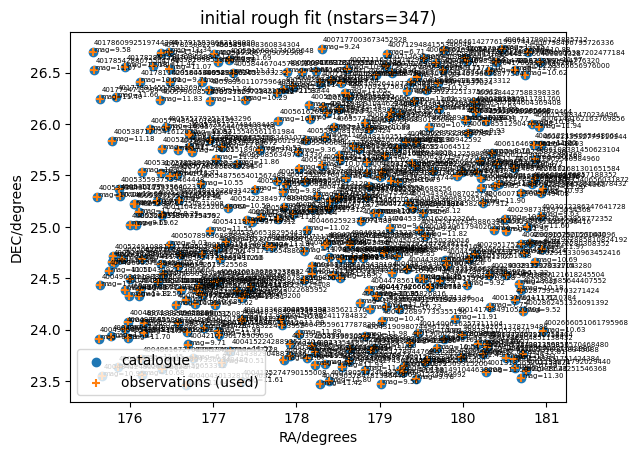

{}
{}
20 20
(347, 20)
20 20
(347, 20)
20 20
(347, 20)
[-3.74977827e-14 -4.52877173e-02 -6.95517659e-08 -6.05473100e-01
  2.30906382e-01 -1.74400611e-01  1.29327489e+01 -5.19117561e-01
  1.17078698e+01  7.39679572e-02 -5.71542403e-03  2.74058607e-02
  5.20120604e-02 -2.56195750e-01 -1.07903208e-01 -7.03919971e+00
  2.98473577e-01 -1.45416034e+01  7.22377642e-01 -6.33802046e+00
 -3.90579305e-01]
[ 2.22909191e-12  3.32897464e-01  4.52876210e-02  8.40426668e-02
 -4.68889161e-01  2.78586451e-01 -1.68519097e-01  1.21110294e+01
 -2.80228883e-01  1.21145723e+01 -5.73699711e-02  1.01203451e-02
 -1.37813252e-02  2.63877858e-01  1.62214464e-02  1.35831395e-01
 -7.44169277e+00  2.49157487e-01 -1.40575184e+01  3.19025827e-01
 -5.94937035e+00]


/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


pre-outlier removed rms error (arcseconds): 0.17982885478840022
SELECT source_id, phot_g_mean_mag, ra, dec, ref_epoch FROM gaiadr3.gaia_source WHERE ((ra BETWEEN 176.05233 AND 176.05791 AND dec BETWEEN  25.21558 AND 25.22113) OR (ra BETWEEN 178.84861 AND 178.85462 AND dec BETWEEN  25.51931 AND 25.52487) OR (ra BETWEEN 178.96933 AND 179.20029 AND dec BETWEEN  26.67670 AND 26.68226) OR (ra BETWEEN 176.73593 AND 176.77105 AND dec BETWEEN  23.71800 AND 23.72355) OR (ra BETWEEN 175.93983 AND 175.95264 AND dec BETWEEN  24.00767 AND 24.01323) OR (ra BETWEEN 176.82680 AND 176.83412 AND dec BETWEEN  24.42144 AND 24.42699) OR (ra BETWEEN 180.67108 AND 180.67826 AND dec BETWEEN  24.44309 AND 24.44865) OR (ra BETWEEN 180.31825 AND 180.32736 AND dec BETWEEN  24.21520 AND 24.22075) OR (ra BETWEEN 180.69045 AND 180.69611 AND dec BETWEEN  25.32328 AND 25.32883) OR (ra BETWEEN 179.51558 AND 179.52114 AND dec BETWEEN  25.13503 AND 25.14058) OR (ra BETWEEN 179.80272 AND 179.80906 AND dec BETWEEN  24.6254

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


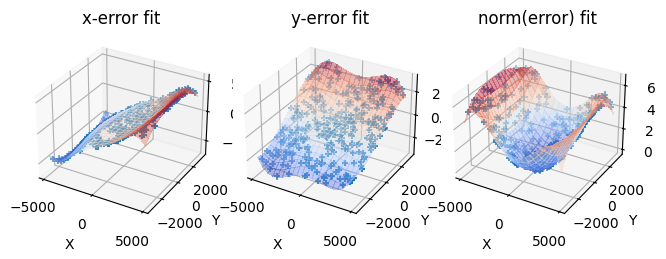

final rms error (arcseconds): 0.07331334913175358
nearest neighbour corr=0.3110062404650873, mean distance:224.5645194333351


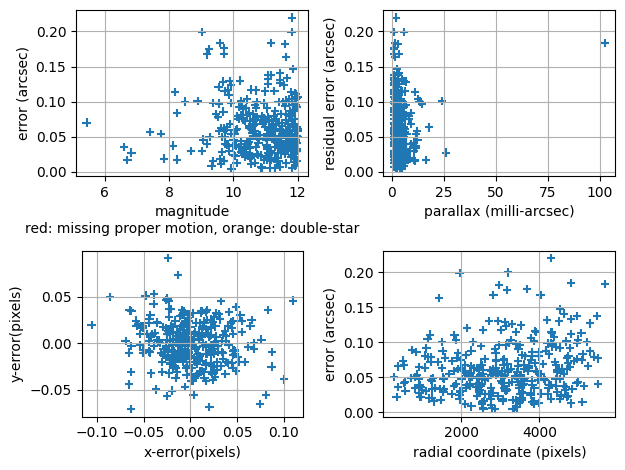

(347, 20)

✅ SUCCESS! Zenith distortion fitting complete!

📁 Check your output directory for the results:
   /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab2

   Look for files named:
   - distortion_data{timestamp}.zip  (main output file)
   - DISTORTION_OUTPUT{timestamp}/   (output folder)

⭐ IMPORTANT: Save this distortion file — Step 4 needs it!
➡️  Next: Go to Step 3 (Eclipse Centroids) to process eclipse images


In [6]:
# ============================================================================
# STEP 2: COMPUTE ZENITH DISTORTION MODEL
# ============================================================================
#
# PREREQUISITE: Run the Step 2 CONFIG cell above first.
# If you see NameError for output_directory, reload this notebook from disk
# (File → Revert / close and reopen), then Kernel → Restart & Run All.
# ============================================================================

import os

if 'options' not in globals() or 'centroid_zip_path' not in globals():
    raise RuntimeError("Run the Step 2 CONFIG cell above before this cell.")

# Output path for messages (always derived from config — never a bare output_directory)
step2_out = (
    globals().get('step2_output_directory')
    or options.get('output_dir')
    or os.path.dirname(centroid_zip_path)
)

print("=" * 60)
print("STEP 2: FITTING ZENITH DISTORTION MODEL")
print("=" * 60)
print()
print(f"Input file: {os.path.basename(centroid_zip_path)}")
print(f"Output directory: {step2_out}")
print()
print("This step will:")
print("  1. Load star positions from Step 1")
print("  2. Match stars to Gaia catalog (may take a few minutes)")
print("  3. Fit distortion polynomial")
print()
print("Starting processing...")
print()

try:
    distortion_fitter.match_and_fit_distortion(
        centroid_zip_path,
        options,
        None,
    )

    print()
    print("=" * 60)
    print("✅ SUCCESS! Zenith distortion fitting complete!")
    print("=" * 60)
    print()
    print("📁 Check your output directory for the results:")
    print(f"   {step2_out}")
    print()
    print("   Look for files named:")
    print("   - distortion_data{timestamp}.zip  (main output file)")
    print("   - DISTORTION_OUTPUT{timestamp}/   (output folder)")
    print()
    print("⭐ IMPORTANT: Save this distortion file — Step 4 needs it!")
    print("➡️  Next: Go to Step 3 (Eclipse Centroids) to process eclipse images")

except Exception as e:
    print()
    print("=" * 60)
    print("❌ ERROR during distortion fitting!")
    print("=" * 60)
    print(f"Error message: {e}")
    print()
    print("Common issues:")
    print("  - Step 1 output file is invalid or corrupted")
    print("  - Not enough stars matched to Gaia catalog")
    print("  - Internet connection needed for Gaia queries")
    print("  - Observation date incorrect (affects star positions)")
    print("  - Plate solving failed in Step 1")
    raise


### Step 2 Results

Finds the zenith distortion ZIP and saves its path as `step2_output_file` — Step 4 will use this as its reference distortion file.

In [7]:
# ============================================================================
# DISPLAY ZENITH DISTORTION RESULTS
# ============================================================================
# This cell finds the output files created by Step 2 and saves the distortion
# file path for use in Step 4 (Eclipse Distortion).
# ============================================================================

# Determine output directory
step2_out = (
    globals().get('step2_output_directory')
    or (options.get('output_dir') if 'options' in globals() else None)
    or os.path.dirname(centroid_zip_path)
)
if step2_out and os.path.isdir(step2_out):
    output_path = Path(step2_out)
else:
    output_path = Path(centroid_zip_path).parent

print("=" * 60)
print("STEP 2 OUTPUT FILES")
print("=" * 60)
print()
print(f"Searching in: {output_path}")
print()

# Find distortion ZIP files (sorted by modification time, newest first)
distortion_zips = sorted(
    output_path.glob("distortion_data*.zip"), 
    key=lambda x: x.stat().st_mtime, 
    reverse=True
)

# Find output directories
output_dirs = sorted(
    output_path.glob("DISTORTION_OUTPUT*"), 
    key=lambda x: x.stat().st_mtime if x.is_dir() else 0, 
    reverse=True
)

if distortion_zips:
    latest_distortion_zip = distortion_zips[0]
    print("✅ Found output files!")
    print()
    print(f"📦 Zenith distortion file (needed for Step 4):")
    print(f"   Name: {latest_distortion_zip.name}")
    print(f"   Full path: {latest_distortion_zip}")
    print(f"   Size: {latest_distortion_zip.stat().st_size / (1024*1024):.2f} MB")
    print()
    print("📝 This ZIP file contains:")
    print("   - Distortion polynomial coefficients (all orders)")
    print("   - Matched stars with position errors")
    print("   - Refined plate solution")
    print()
    
    # Store for use in Step 4 (Eclipse Distortion)
    step2_output_file = str(latest_distortion_zip)
    print(f"💾 Saved as 'step2_output_file' — Step 4 will use this as reference")
    print()
    
    if output_dirs:
        print(f"📁 Output directory: {output_dirs[0].name}")
        print(f"   Contains plots, logs, and intermediate files")
        print()
    
    # Try to peek inside the ZIP to show what's there
    try:
        with zipfile.ZipFile(latest_distortion_zip, 'r') as z:
            file_list = z.namelist()
            print("📋 Files inside ZIP:")
            for f in file_list[:10]:  # Show first 10 files
                print(f"   - {f}")
            if len(file_list) > 10:
                print(f"   ... and {len(file_list) - 10} more files")
    except:
        pass  # If we can't read it, that's okay
    
    print()
    print("=" * 60)
    print("✅ Step 2 Complete! Zenith calibration done.")
    print("=" * 60)
    print()
    print("➡️  Next: Go to Step 3 to process your eclipse images")
    print("   The zenith distortion file will be used in Step 4")
    
else:
    print("⚠️  No output files found!")
    print()
    print("This could mean:")
    print("  - Processing is still running (check above for progress)")
    print("  - An error occurred (check error messages above)")
    print("  - Output directory is different than expected")
    print()
    print(f"   Searched in: {output_path}")
    print("   Looking for files matching: distortion_data*.zip")
    print()
    print("💡 Tip: If processing completed successfully, the output file")
    print("   should be in the same directory as your Step 1 output.")


STEP 2 OUTPUT FILES

Searching in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab2

✅ Found output files!

📦 Zenith distortion file (needed for Step 4):
   Name: distortion_data20260619142330__centroid_data2026061913083020260619130830.zip
   Full path: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/zenith_calibration_tab2/distortion_data20260619142330__centroid_data2026061913083020260619130830.zip
   Size: 0.03 MB

📝 This ZIP file contains:
   - Distortion polynomial coefficients (all orders)
   - Matched stars with position errors
   - Refined plate solution

💾 Saved as 'step2_output_file' — Step 4 will use this as reference

📁 Output directory: DISTORTION_OUTPUT20260619142330__centroid_data2026061913083020260619130830
   Contains plots, logs, and intermediate files

📋 Files inside ZIP:
   - distortion_results.txt
   - CATALOGUE_MATCHED_ERRORS.csv

✅ Step 2 Complete! Zenith calibration done.

➡️

---

## 📍 Step 3 — Find Centroids (Eclipse Images)

**What:** Stack eclipse images, find star positions (centroids), and plate-solve the field.

**Why:** Eclipse images include the Sun — blob masking is required. Same `do_stack()` as Step 1.

| | |
|---|---|
| **Inputs** | FITS eclipse light / dark / flat files (you set paths and order below) |
| **Outputs** | `centroid_data{timestamp}.zip` in `MEE2024_outputs/eclipse_tab1/` |
| **Feeds into** | Step 4 (Eclipse Distortion) |
| **GUI equivalent** | Tab 1 (eclipse data) |
| **Pass check** | `n_centroids: 252` in `results.txt`; CSVs match `Final SD GUI Runs/06-19 Eclipse Tab 1/centroid_data20260619145918.zip` |

**📋 Edit in the configuration cell:**
1. `eclipse_light_files` — order matters (first file = reference frame)
2. `eclipse_dark_files` / `eclipse_flat_files` — optional
3. `TAB3_SETTINGS` — match your GUI Tab 1 eclipse run (blob on, etc.)

---

In [8]:
# ============================================================================
# STEP 3 (GUI TAB 1) — Find centroids (Eclipse)
# ============================================================================
# Same layout as Step 1. Settings below match Final SD GUI eclipse Tab 1 (Jun 19).
# Compare Step 3 output to:
#   Final SD GUI Runs/06-19 Eclipse Tab 1/centroid_data20260619145918.zip
# Pass check: n_centroids=252; STACKED_CENTROIDS_*.csv byte-identical to that run.
# ============================================================================

from pathlib import Path

# ----------------------------------------------------------------------------
# 1) Select your files (YOU EDIT)
# ----------------------------------------------------------------------------

# Eclipse light (science) frames — order 0029→0020 (matches validated GUI run).
# First file = reference frame for stacking.
eclipse_light_files = [
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0029.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0028.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0027.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0026.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0025.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0024.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0023.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0022.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0021.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/science/2024-04-08-1810_4-CapObj_0020.FIT",
]

# Eclipse dark frames (optional) — keep index alignment with lights if used
eclipse_dark_files = [
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0029.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0028.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0027.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0026.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0025.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0024.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0023.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0022.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0021.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/dark/2024-04-08-1900_2-CapObj_0020.FIT",
]

# Eclipse flat frames (optional) — keep index alignment with lights if used
eclipse_flat_files = [
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0029.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0028.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0027.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0026.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0025.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0024.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0023.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0022.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0021.FIT",
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE 2024 Sample Data/eclipse/flat/2024-04-08-1921_4-CapObj_0020.FIT",
]

# Output folder
step3_output_directory = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/eclipse_tab1"
)

Path(step3_output_directory).mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# 2) Tab 1 settings (YOU EDIT) — eclipse field
# ----------------------------------------------------------------------------

TAB3_SETTINGS = {
    # Show graphics  — GUI: ☑ Show graphics
    'flag_display': True,

    'save_dark_flat': False,
    'float_fits': False,

    # GUI: Show the brightest stars in stack
    'd': 200,

    # GUI: Remove big bright object (blob) — ON for eclipse / Sun in field
    'delete_saturated_blob': True,
    'blob_saturation_level': 95,
    'blob_radius_extra': 200,      # GUI screenshot value
    'centroid_gap_blob': 100,      # GUI screenshot value

    # GUI: Sensitive stacking mode ☑   →   centroid_gaussian_subtract = True
    'centroid_gaussian_subtract': True,
    # GUI: Use sensitive mode on stacked result ☑
    'sensitive_mode_stack': True,

    'centroid_gaussian_thresh': 4.0,
    'min_area': 2,
    'sigma_subtract': 0.0,
    'background_subtraction_mode': 'annular',

    'remove_edgy_centroids': True,

    # Skip the interactive X/Y transcept overlay; static "chosen stars" plot is enough.
    'show_scanlines': False,
}

# ----------------------------------------------------------------------------
# 3) Defaults you do NOT touch (internal)
# ----------------------------------------------------------------------------

TAB3_DO_NOT_TOUCH = {
    'm': 30,
    'n': 30,
    'pxl_tol': 10,
    'cutoff': 100,
    'img_edge_distance': 5,
    'rough_match_threshhold': 36,
    'sanity_check_centroids': True,
    'experimental_background_subtract': False,
    'workDir': '',
    'workDir2': '',
    '-DARK-': '',
    '-FLAT-': '',
    'database': '',
    'flag_debug': False,
    'flag_display2': False,
}

step3_options = {
    **TAB3_DO_NOT_TOUCH,
    **TAB3_SETTINGS,
    'output_dir': step3_output_directory,
}

print("✅ Step 3 (Tab 1) configuration loaded!")
print(f"   Eclipse light files: {len(eclipse_light_files)}")
print(f"   Eclipse dark files:  {len(eclipse_dark_files)}")
print(f"   Eclipse flat files:  {len(eclipse_flat_files)}")
print(f"   Output directory:   {step3_output_directory}")
print(f"   Tab 1 key settings: d={step3_options['d']}, blob={step3_options['delete_saturated_blob']}, sensitive={step3_options['sensitive_mode_stack']}")
print("   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 1/centroid_data20260619145918.zip")
print("   Pass check: n_centroids=252")


✅ Step 3 (Tab 1) configuration loaded!
   Eclipse light files: 10
   Eclipse dark files:  10
   Eclipse flat files:  10
   Output directory:   /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1
   Tab 1 key settings: d=200, blob=True, sensitive=True
   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 1/centroid_data20260619145918.zip
   Pass check: n_centroids=252


### Validate Eclipse Input Files

Before processing, check that all eclipse file paths exist and can be opened (same as Step 1).

In [9]:
# ============================================================================
# VALIDATE ECLIPSE INPUT FILES
# ============================================================================
# Self-contained: defines validate_files inline so this cell works whether or
# not the Setup cell or Step 1 validate cell were run first.

import os


def validate_files(file_list, file_type="light"):
    valid_files = []
    for file_path in file_list:
        if not file_path:
            continue
        if not os.path.exists(file_path):
            print(f"⚠️  WARNING: {file_type} file not found: {file_path}")
            continue
        try:
            with open(file_path, "rb") as f:
                pass
            valid_files.append(file_path)
            print(f"✅ Valid {file_type} file: {os.path.basename(file_path)}")
        except Exception as e:
            print(f"❌ ERROR: Cannot open {file_type} file {file_path}: {e}")
    return valid_files


print("=" * 60)
print("VALIDATING ECLIPSE INPUT FILES")
print("=" * 60)
print()

valid_eclipse_light_files = validate_files(eclipse_light_files, "eclipse light")
valid_eclipse_dark_files = validate_files(eclipse_dark_files, "eclipse dark")
valid_eclipse_flat_files = validate_files(eclipse_flat_files, "eclipse flat")

print()
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"   Eclipse light files: {len(valid_eclipse_light_files)} valid out of {len(eclipse_light_files)} specified")
print(f"   Eclipse dark files:  {len(valid_eclipse_dark_files)} valid out of {len(eclipse_dark_files)} specified")
print(f"   Eclipse flat files:  {len(valid_eclipse_flat_files)} valid out of {len(eclipse_flat_files)} specified")
print()

if len(valid_eclipse_light_files) == 0:
    print("❌ ERROR: No valid eclipse light files found!")
    print("   Please check your file paths in the Step 3 configuration cell above.")
    raise ValueError("No valid eclipse light files provided.")
else:
    print("✅ Validation complete! Ready to process eclipse images.")
    print(f"   Processing {len(valid_eclipse_light_files)} eclipse frame(s)...")


VALIDATING ECLIPSE INPUT FILES

✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0029.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0028.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0027.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0026.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0025.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0024.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0023.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0022.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0021.FIT
✅ Valid eclipse light file: 2024-04-08-1810_4-CapObj_0020.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_2-CapObj_0029.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_2-CapObj_0028.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_2-CapObj_0027.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_2-CapObj_0026.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_2-CapObj_0025.FIT
✅ Valid eclipse dark file: 2024-04-08-1900_

### Run Step 3: Stack Eclipse Images and Find Centroids

Calls `stacker_implementation.do_stack()` — same function as Step 1 / GUI Tab 1.

STEP 3: STACKING ECLIPSE IMAGES AND FINDING CENTROIDS

Processing 10 eclipse light frame(s)...
Using 10 dark frame(s) for noise reduction
Using 10 flat frame(s) for vignetting correction
Blob masking: ON

This may take several minutes depending on:
  - Number of images
  - Image size
  - Number of stars in the field

Starting processing...

logpath /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1/CENTROID_OUTPUT20260619150521/LOG20260619150521.txt
using version:v0.6.0
using options:{'m': 30, 'n': 30, 'pxl_tol': 10, 'cutoff': 100, 'img_edge_distance': 5, 'rough_match_threshhold': 36, 'sanity_check_centroids': True, 'experimental_background_subtract': False, 'workDir': '', 'workDir2': '', '-DARK-': '', '-FLAT-': '', 'database': '', 'flag_debug': False, 'flag_display2': False, 'flag_display': True, 'save_dark_flat': False, 'float_fits': False, 'd': 200, 'delete_saturated_blob': True, 'blob_saturation_level': 95, 'blob_radius_extra': 200, 'centr

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/skimage/measure/_regionprops.py:723: RuntimeWarning: invalid value encountered in scalar divide
  tuple(M[_get_element(axis)] / M0 for axis in range(self._ndim))


  7/10
--- 0.7471911907196045 seconds for centroid finding (prepare)---
--- 1.2010540962219238 seconds for centroid finding (labelling)---
n centroids initial 100
n centroids sanity-filtered 78
--- 1.3921451568603516 seconds for centroid finding (all)---
found: [(np.float32(1182.7985), np.float64(40.0), (np.float64(1883.2208680747528), np.float64(7876.945260258389))), (np.float32(654.44867), np.float64(36.0), (np.float64(6238.447799549292), np.float64(6966.014021947622))), (np.float32(560.2695), np.float64(31.0), (np.float64(4612.010776393673), np.float64(9398.885940958728))), (np.float32(559.4592), np.float64(32.0), (np.float64(6260.7229979845915), np.float64(5278.496890619723))), (np.float32(446.25464), np.float64(29.0), (np.float64(2515.5754464863844), np.float64(2673.7039671940065))), (np.float32(429.5112), np.float64(30.0), (np.float64(3645.766549782106), np.float64(2205.0227157667873))), (np.float32(208.26743), np.float64(20.0), (np.float64(788.2627507370073), np.float64(8618.224

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


--- 0.833791971206665 seconds for centroid finding (prepare)---
--- 1.328613042831421 seconds for centroid finding (labelling)---
n centroids initial 116
n centroids sanity-filtered 99
--- 1.5497000217437744 seconds for centroid finding (all)---
found: [(np.float32(1219.8489), np.float64(42.0), (np.float64(1883.707896435896), np.float64(7877.216841233229))), (np.float32(653.2687), np.float64(31.0), (np.float64(4612.169955496479), np.float64(9399.266710112164))), (np.float32(598.37427), np.float64(29.0), (np.float64(6260.797864795411), np.float64(5278.704267589959))), (np.float32(585.96246), np.float64(34.0), (np.float64(6237.49704599612), np.float64(6966.4270218600295))), (np.float32(470.79666), np.float64(27.0), (np.float64(3645.3403214531377), np.float64(2205.063079085666))), (np.float32(414.1427), np.float64(26.0), (np.float64(2515.6638425529763), np.float64(2673.3472488220095))), (np.float32(216.97626), np.float64(22.0), (np.float64(788.4523884675247), np.float64(8618.228576928295)

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/.venv/lib/python3.12/site-packages/skimage/measure/_regionprops.py:723: RuntimeWarning: invalid value encountered in scalar divide
  tuple(M[_get_element(axis)] / M0 for axis in range(self._ndim))


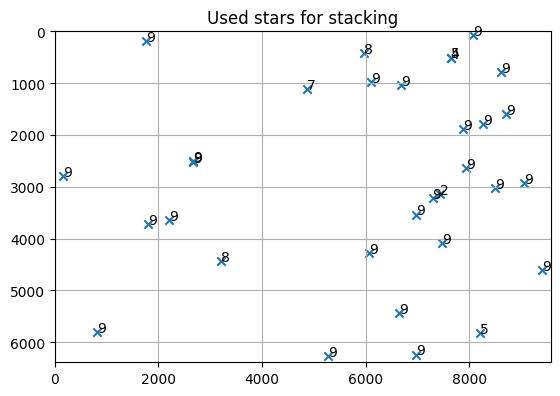

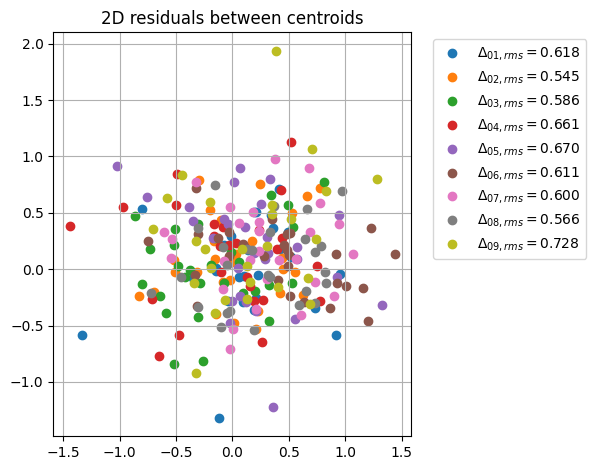

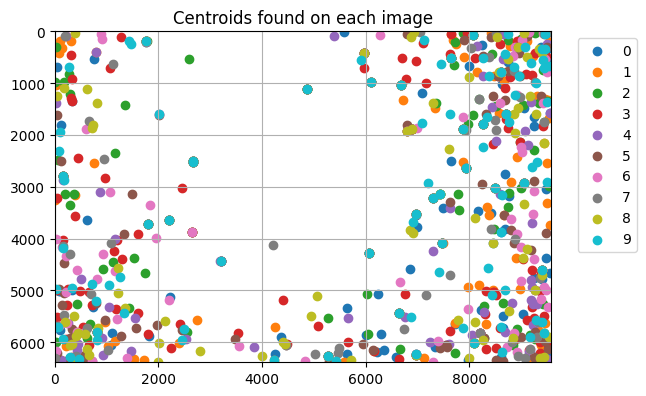

Stacking images...
  1/10
  2/10
  3/10
  4/10
  5/10
  6/10
  7/10
  8/10
  9/10
  10/10
--- 2.1877620220184326 seconds for centroid finding (prepare)---
--- 2.9763081073760986 seconds for centroid finding (labelling)---
n centroids initial 311
n centroids sanity-filtered 253
--- 3.3563320636749268 seconds for centroid finding (all)---
found: [(np.float64(3376.079716440758), np.float64(46.0), (np.float64(1883.6752973402458), np.float64(7877.311742227698))), (np.float64(1054.246605472176), np.float64(39.0), (np.float64(4612.078247640666), np.float64(9399.045409443714))), (np.float64(1036.1589275920078), np.float64(39.0), (np.float64(6237.98382509707), np.float64(6966.289262680427))), (np.float64(1019.3703830053263), np.float64(38.0), (np.float64(6260.632719175725), np.float64(5279.055130515601))), (np.float64(949.6615891642656), np.float64(36.0), (np.float64(2515.6735699160126), np.float64(2673.287712875819))), (np.float64(841.1690943988632), np.float64(36.0), (np.float64(3645.14993636

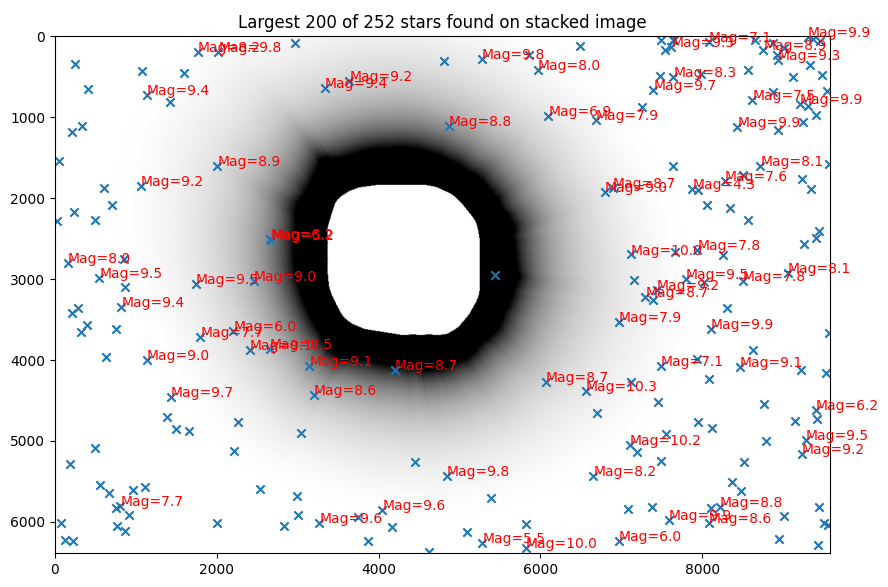

making archive /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1/CENTROID_OUTPUT20260619150521 /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1
Done!

✅ SUCCESS! Eclipse image stacking complete!

📁 Check your output directory for the results:
   Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1

   Look for files named:
   - centroid_data{timestamp}.zip  (main output file)
   - CENTROID_OUTPUT{timestamp}/    (output folder)

➡️  This ZIP file will be used as input for Step 4 (Eclipse Distortion)


<Figure size 640x480 with 0 Axes>

In [10]:
# ============================================================================
# STEP 3: STACK ECLIPSE IMAGES AND FIND STAR CENTROIDS
# ============================================================================
#
# PREREQUISITE: Run Setup cell → Step 3 CONFIG → Validate eclipse files, in that order.
# Function called: stacker_implementation.do_stack()  (same as GUI Tab 1 / Step 1)
#
# Output: centroid_data{timestamp}.zip → used in Step 4
# ============================================================================

print("=" * 60)
print("STEP 3: STACKING ECLIPSE IMAGES AND FINDING CENTROIDS")
print("=" * 60)
print()
print(f"Processing {len(valid_eclipse_light_files)} eclipse light frame(s)...")
if valid_eclipse_dark_files:
    print(f"Using {len(valid_eclipse_dark_files)} dark frame(s) for noise reduction")
if valid_eclipse_flat_files:
    print(f"Using {len(valid_eclipse_flat_files)} flat frame(s) for vignetting correction")
print(f"Blob masking: {'ON' if step3_options['delete_saturated_blob'] else 'OFF'}")
print()
print("This may take several minutes depending on:")
print("  - Number of images")
print("  - Image size")
print("  - Number of stars in the field")
print()
print("Starting processing...")
print()

try:
    stacker_implementation.do_stack(
        valid_eclipse_light_files,
        valid_eclipse_dark_files,
        valid_eclipse_flat_files,
        step3_options,
    )

    print()
    print("=" * 60)
    print("✅ SUCCESS! Eclipse image stacking complete!")
    print("=" * 60)
    print()
    print("📁 Check your output directory for the results:")
    print(f"   Output directory: {step3_output_directory}")
    print()
    print("   Look for files named:")
    print("   - centroid_data{timestamp}.zip  (main output file)")
    print("   - CENTROID_OUTPUT{timestamp}/    (output folder)")
    print()
    print("➡️  This ZIP file will be used as input for Step 4 (Eclipse Distortion)")

except Exception as e:
    print()
    print("=" * 60)
    print("❌ ERROR during eclipse stacking!")
    print("=" * 60)
    print(f"Error message: {e}")
    print()
    print("Common issues:")
    print("  - File paths incorrect (check Step 3 configuration cell)")
    print("  - Images corrupted or wrong format")
    print("  - Not enough stars in images for plate solving")
    print("  - Blob masking settings need adjustment")
    print()
    raise


### Step 3 Results

Finds the output ZIP and saves its path as `step3_output_file` for Step 4.

In [5]:
# ============================================================================
# STEP 3 OUTPUT FILES
# ============================================================================

from pathlib import Path
if step3_output_directory and os.path.isdir(step3_output_directory):
    step3_output_path = Path(step3_output_directory)
else:
    step3_output_path = Path(valid_eclipse_light_files[0]).parent

print("=" * 60)
print("STEP 3 OUTPUT FILES")
print("=" * 60)
print()
print(f"Searching in: {step3_output_path}")
print()

centroid_zips = sorted(
    step3_output_path.glob("centroid_data*.zip"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

output_dirs = sorted(
    step3_output_path.glob("CENTROID_OUTPUT*"),
    key=lambda x: x.stat().st_mtime if x.is_dir() else 0,
    reverse=True,
)

if centroid_zips:
    latest_zip = centroid_zips[0]
    print("✅ Found output files!")
    print()
    print("📦 Main output file (for Step 4):")
    print(f"   Name: {latest_zip.name}")
    print(f"   Full path: {latest_zip}")
    print(f"   Size: {latest_zip.stat().st_size / (1024*1024):.2f} MB")
    print()
    print("📝 This ZIP file contains:")
    print("   - Star positions (centroids) in pixel coordinates")
    print("   - Plate solution (RA, Dec, roll, plate scale)")
    print("   - Stacked image data")
    print("   - Processing log")
    print()

    step3_output_file = str(latest_zip)
    print("💾 Saved as 'step3_output_file' for use in Step 4")
    print()

    if output_dirs:
        print(f"📁 Output directory: {output_dirs[0].name}")
        print("   Contains plots, logs, and intermediate files")
        print()

    print("=" * 60)
    print("✅ Step 3 Complete! Ready for Step 4 (Eclipse Distortion).")
    print("=" * 60)
    print()
    print("➡️  Next: Go to Step 4 section below")
    print("   The output file path will be used automatically")

else:
    print("⚠️  No output files found!")
    print()
    print(f"   Searched in: {step3_output_path}")
    print("   Looking for files matching: centroid_data*.zip")
    print()
    print("💡 Tip: Run the Step 3 processing cell above first.")


STEP 3 OUTPUT FILES

Searching in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1

✅ Found output files!

📦 Main output file (for Step 4):
   Name: centroid_data20260521171321.zip
   Full path: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab1/centroid_data20260521171321.zip
   Size: 0.01 MB

📝 This ZIP file contains:
   - Star positions (centroids) in pixel coordinates
   - Plate solution (RA, Dec, roll, plate scale)
   - Stacked image data
   - Processing log

💾 Saved as 'step3_output_file' for use in Step 4

📁 Output directory: CENTROID_OUTPUT20260521171321
   Contains plots, logs, and intermediate files

✅ Step 3 Complete! Ready for Step 4 (Eclipse Distortion).

➡️  Next: Go to Step 4 section below
   The output file path will be used automatically


---

## 🔧 Step 4 — Compute Distortion (Eclipse Field)

**What:** Match eclipse stars to Gaia and refit distortion — same `match_and_fit_distortion()` as Step 2.

**Why:** Higher-order distortion comes from zenith (Step 2). Eclipse run freezes quad+ and refits **linear** plate scale / pointing only.

| | |
|---|---|
| **Inputs** | `centroid_data*.zip` from Step 3 + zenith `distortion_data*.zip` from Step 2 |
| **Outputs** | `distortion_data*.zip` in `MEE2024_outputs/eclipse_tab2/` |
| **Feeds into** | Step 5 (Deflection / L) |
| **GUI equivalent** | Tab 2 on eclipse data; **Fix order higher than** = `linear`; **Fix distortion file** = zenith distortion zip |
| **Pass check** | `#stars used: 64`, `gravity_sweep_L ≈ 1.177` in `distortion_results.txt`; compare to `Final SD GUI Runs/06-19 Eclipse Tab 2/distortion_data20260619152026…` |

**📋 Edit in the configuration cell:** input zip paths, `TAB4_SETTINGS` (match your GUI eclipse Tab 2).

---

In [14]:
# ============================================================================
# STEP 4 (GUI TAB 2) — Compute distortion (Eclipse field)
# ============================================================================
# Same layout as Step 2. YOU EDIT: paths, Tab 2 settings (eclipse + frozen zenith coeffs).
# ============================================================================

from pathlib import Path
import os

# ─────────────────────────────────────────────────────────────────────────────
# 1) FILES & FOLDERS  (top of Tab 2 window)
# ─────────────────────────────────────────────────────────────────────────────

# GUI: "File(s)" — eclipse centroid zip from Step 3 / Tab 1 eclipse
# Validated notebook Step 3 output (CSVs byte-identical to Final SD GUI Tab 1
# centroid_data20260619145918.zip). Compare Step 4 output to:
# Final SD GUI Runs/06-19 Eclipse Tab 2/distortion_data20260619152026…
eclipse_centroid_zip = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/eclipse_tab1/centroid_data20260619150521.zip"
)

# GUI: "Fix distortion file(s)" — zenith calibration from Step 2
# Validated notebook Step 2 output (327 stars, same platescale as GUI
# distortion_data20260619134514…). Leave "" to auto-fill from step2_output_file.
zenith_distortion_zip = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/zenith_calibration_tab2/"
    "distortion_data20260619142330__centroid_data2026061913083020260619130830.zip"
)

# GUI: "Fix order higher than" — linear = freeze quad+ from zenith, refit linear on eclipse
distortion_fixed_coefficients = "linear"

# GUI: "Output folder"
step4_output_directory = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2"
)

Path(step4_output_directory).mkdir(parents=True, exist_ok=True)

# Auto-fill from prior steps if paths left blank
if not eclipse_centroid_zip and globals().get("step3_output_file"):
    eclipse_centroid_zip = step3_output_file
if not zenith_distortion_zip and globals().get("step2_output_file"):
    zenith_distortion_zip = step2_output_file


# ─────────────────────────────────────────────────────────────────────────────
# 2) TAB 2 SETTINGS  (YOU EDIT — match GUI eclipse Tab 2)
# ─────────────────────────────────────────────────────────────────────────────

TAB4_SETTINGS = {

    "flag_display2": True,

    "max_star_mag_dist": 12.0,
    "guess_date": False,
    "observation_date": "2024-04-08",

    "distortion_fit_tol": 2.0,
    "distortionOrder": "quintic",

    "rough_match_threshhold": 100.0,

    "crop_circle": False,
    "crop_circle_thresh": 0.8,

    "remove_double_tab2": True,

    "enable_corrections": True,
    "enable_gravitational_def": False,

    # GUI: ☑ Simultaneous deflection constant and platescale fit
    "gravity_sweep": True,

    "observation_time": "18:12",
    "observation_lat": "23.8495",
    "observation_long": "-105.2728",

    "enable_corrections_ref": True,

    "observation_temp": 15.0,
    "observation_pressure": 760.0,
    "observation_humidity": 0.25,
    "observation_height": 2400.0,
    "observation_wavelength": 0.625,

    "distortion_reference_files": zenith_distortion_zip,
    "distortion_fixed_coefficients": distortion_fixed_coefficients,
}


# ─────────────────────────────────────────────────────────────────────────────
# 3) INTERNAL DEFAULTS  (not shown on Tab 2 GUI)
# ─────────────────────────────────────────────────────────────────────────────

TAB4_INTERNAL = {
    "catalogue": "gaia",
    "safety_limit_mag": 13,
    "double_star_cutoff": 10,
    "double_star_mag": 17,
    "DEFAULT_DATE": "2020-01-01",
    "basis_type": "polynomial",
    "workDir": "",
    "workDir2": "",
    "database": "",
    "flag_debug": False,
    "flag_display": False,
}

step4_options = {**TAB4_INTERNAL, **TAB4_SETTINGS, "output_dir": step4_output_directory}
step4_centroid_zip_path = eclipse_centroid_zip

# ─────────────────────────────────────────────────────────────────────────────
# Validate input files
# ─────────────────────────────────────────────────────────────────────────────

if not eclipse_centroid_zip:
    raise ValueError(
        "eclipse_centroid_zip is required. Run Step 3 or set the path in this cell."
    )
if not zenith_distortion_zip:
    raise ValueError(
        "zenith_distortion_zip is required. Run Step 2 or set the path in this cell."
    )

for label, path in [
    ("Eclipse centroids", eclipse_centroid_zip),
    ("Zenith distortion reference", zenith_distortion_zip),
]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label} file not found: {path}")

print("✅ Step 4 (Tab 2) configuration loaded!")
print(f"   Eclipse centroid zip: {os.path.basename(eclipse_centroid_zip)}")
print(f"   Zenith reference zip: {os.path.basename(zenith_distortion_zip)}")
print(f"   Fixed coefficients:   {distortion_fixed_coefficients}")
print(f"   Output directory:     {step4_output_directory}")


✅ Step 4 (Tab 2) configuration loaded!
   Eclipse centroid zip: centroid_data20260619150521.zip
   Zenith reference zip: distortion_data20260619142330__centroid_data2026061913083020260619130830.zip
   Fixed coefficients:   linear
   Output directory:     /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2


### Run Step 4: Fit Eclipse Distortion Model

Calls `distortion_fitter.match_and_fit_distortion()` — same function as Step 2 / GUI Tab 2 (eclipse).

STEP 4: FITTING ECLIPSE DISTORTION MODEL

Input file: centroid_data20260619150521.zip
Zenith reference: distortion_data20260619142330__centroid_data2026061913083020260619130830.zip
Fixed coefficients: linear
Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2

This step will:
  1. Load eclipse star positions from Step 3
  2. Match stars to Gaia catalog
  3. Apply frozen higher-order distortion from zenith (Step 2)
  4. Refit linear plate scale / pointing on eclipse field

Starting processing...

loaded database
 Real time loading: 0.00 seconds
mean: [793.49721959 100.55922083]
 Real time prepare: 0.54 seconds
 Real time match: 0.16 seconds
 Real time platescale compute: 0.35 seconds
initial triangle matches: 738098
triangle match: 72 [(0, 1, 6), (0, 1, 7), (0, 1, 8), (0, 1, 10), (0, 1, 11), (0, 1, 15), (0, 1, 17), (0, 7, 6), (0, 8, 6), (0, 6, 10), (0, 11, 6), (0, 6, 14), (0, 15, 6), (0, 6, 17), (0, 7, 8), (0, 7, 10), (0, 11, 7

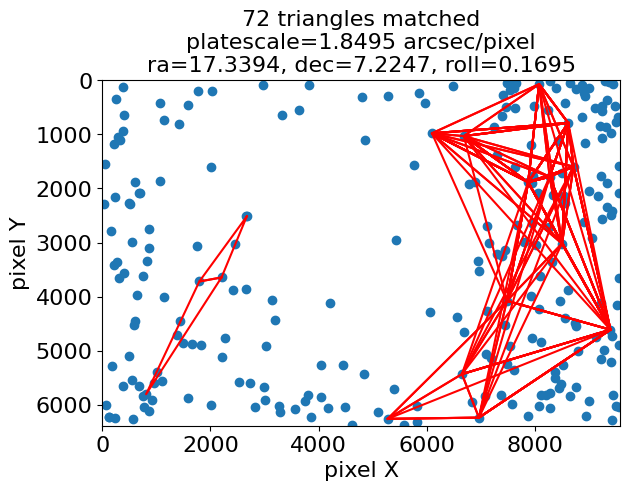

SELECT source_id, phot_g_mean_mag, COORD1(ESDC_EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2024.2833205563466)),COORD2(ESDC_EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2024.2833205563466)), parallax, pmra, pmdec, ref_epoch FROM gaiadr3.gaia_source WHERE ra BETWEEN 14.845589910238246 AND 19.82409100275263 AND dec BETWEEN 5.570407126703555 AND 8.866180891899242 AND phot_g_mean_mag BETWEEN 3 AND 12.0
INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 439
     SOURCE_ID      phot_g_mean_mag       COORD1             COORD2           parallax              pmra               pmdec        ref_epoch
                          mag                                                   mas               mas / yr            mas / yr          yr   
------------------- --------------- ------------------ ----------------- ------------------ ------------------- ------------------- ---------
2576636612713229696        9.750127 18

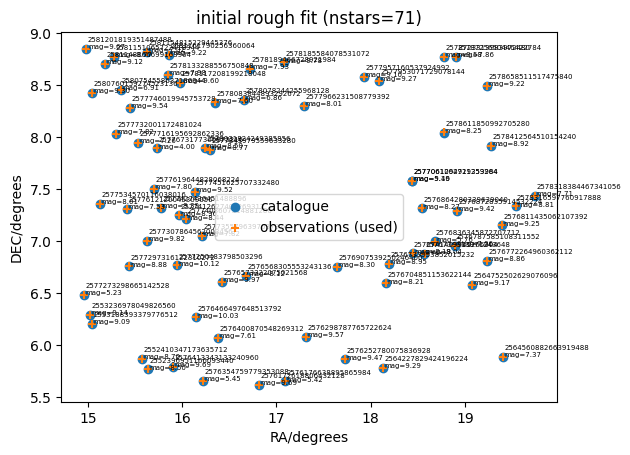

{'1': 5.4399817983608045e-12, 'x': -0.05845641179980299, 'y': -9.200356632099727e-08, 'x^2': -0.6298830778049194, 'x * y': 0.1425956498743699, 'y^2': -0.20566136722401263, 'x^3': 13.061423699394108, 'x^2 * y': -0.38455619111701367, 'x * y^2': 11.877860951282688, 'y^3': -0.17940594459738435, 'x^4': -0.006534514839663358, 'x^3 * y': 0.0022619712407299097, 'x^2 * y^2': 0.11979959404759077, 'x * y^3': 0.05894058878001385, 'y^4': -0.030756769333116996, 'x^5': -7.116093928540545, 'x^4 * y': 0.33028513791472847, 'x^3 * y^2': -14.684596892222139, 'x^2 * y^3': 0.2210299533901381, 'x * y^4': -6.684524199456652, 'y^5': 0.21442942320676295}
{'1': -7.907174914834059e-12, 'x': 0.3654954329739578, 'y': 0.0584565419803898, 'x^2': 0.10832260311011926, 'x * y': -0.43321845739964854, 'y^2': 0.30266030921829234, 'x^3': -0.22342799859450402, 'x^2 * y': 12.015344345751398, 'x * y^2': -0.3319249310375483, 'y^3': 12.278701487804016, 'x^4': -0.0654423198842648, 'x^3 * y': 0.04899536963341622, 'x^2 * y^2': -0.0

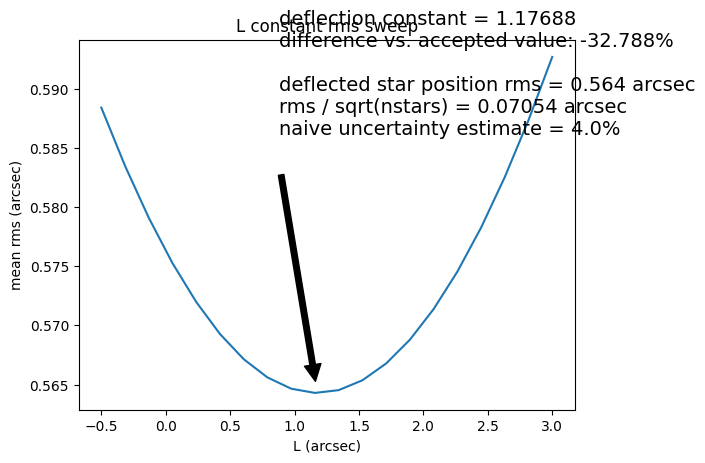

sky mean position alt/az: 69.69582602112726 142.4748525895521
rms diff of corrections (arcsec) 0.05849601311906478
{'1': 5.4399817983608045e-12, 'x': -0.05845641179980299, 'y': -9.200356632099727e-08, 'x^2': -0.6298830778049194, 'x * y': 0.1425956498743699, 'y^2': -0.20566136722401263, 'x^3': 13.061423699394108, 'x^2 * y': -0.38455619111701367, 'x * y^2': 11.877860951282688, 'y^3': -0.17940594459738435, 'x^4': -0.006534514839663358, 'x^3 * y': 0.0022619712407299097, 'x^2 * y^2': 0.11979959404759077, 'x * y^3': 0.05894058878001385, 'y^4': -0.030756769333116996, 'x^5': -7.116093928540545, 'x^4 * y': 0.33028513791472847, 'x^3 * y^2': -14.684596892222139, 'x^2 * y^3': 0.2210299533901381, 'x * y^4': -6.684524199456652, 'y^5': 0.21442942320676295}
{'1': -7.907174914834059e-12, 'x': 0.3654954329739578, 'y': 0.0584565419803898, 'x^2': 0.10832260311011926, 'x * y': -0.43321845739964854, 'y^2': 0.30266030921829234, 'x^3': -0.22342799859450402, 'x^2 * y': 12.015344345751398, 'x * y^2': -0.3319249

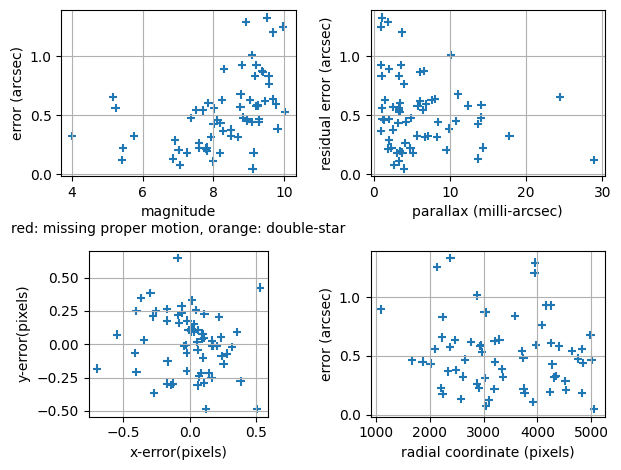

(71, 20)

✅ SUCCESS! Eclipse distortion fitting complete!

📁 Check your output directory for the results:
   /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2

   Look for files named:
   - distortion_data{timestamp}.zip  (main output file)
   - DISTORTION_OUTPUT{timestamp}/   (output folder)

➡️  This ZIP file will be used as input for Step 5 (Deflection Calculation)

   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 2/distortion_data20260619152026…
   Pass check: #stars used=64, gravity_sweep_L≈1.177


In [15]:
# ============================================================================
# STEP 4: COMPUTE ECLIPSE DISTORTION MODEL
# ============================================================================
#
# PREREQUISITE: Run the Step 4 CONFIG cell above first.
# ============================================================================

import os

if "step4_options" not in globals() or "step4_centroid_zip_path" not in globals():
    raise RuntimeError("Run the Step 4 CONFIG cell above before this cell.")

step4_out = (
    globals().get("step4_output_directory")
    or step4_options.get("output_dir")
    or os.path.dirname(step4_centroid_zip_path)
)

print("=" * 60)
print("STEP 4: FITTING ECLIPSE DISTORTION MODEL")
print("=" * 60)
print()
print(f"Input file: {os.path.basename(step4_centroid_zip_path)}")
print(f"Zenith reference: {os.path.basename(step4_options['distortion_reference_files'])}")
print(f"Fixed coefficients: {step4_options['distortion_fixed_coefficients']}")
print(f"Output directory: {step4_out}")
print()
print("This step will:")
print("  1. Load eclipse star positions from Step 3")
print("  2. Match stars to Gaia catalog")
print("  3. Apply frozen higher-order distortion from zenith (Step 2)")
print("  4. Refit linear plate scale / pointing on eclipse field")
print()
print("Starting processing...")
print()

try:
    distortion_fitter.match_and_fit_distortion(
        step4_centroid_zip_path,
        step4_options,
        None,
    )

    print()
    print("=" * 60)
    print("✅ SUCCESS! Eclipse distortion fitting complete!")
    print("=" * 60)
    print()
    print("📁 Check your output directory for the results:")
    print(f"   {step4_out}")
    print()
    print("   Look for files named:")
    print("   - distortion_data{timestamp}.zip  (main output file)")
    print("   - DISTORTION_OUTPUT{timestamp}/   (output folder)")
    print()
    print("➡️  This ZIP file will be used as input for Step 5 (Deflection Calculation)")
    print()
    print("   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 2/distortion_data20260619152026…")
    print("   Pass check: #stars used=64, gravity_sweep_L≈1.177")

except Exception as e:
    print()
    print("=" * 60)
    print("❌ ERROR during eclipse distortion fitting!")
    print("=" * 60)
    print(f"Error message: {e}")
    print()
    print("Common issues:")
    print("  - Step 3 output file is invalid or corrupted")
    print("  - Zenith distortion reference file (Step 2) not found or wrong order")
    print("  - Not enough stars matched to Gaia in eclipse field")
    print("  - Settings do not match GUI eclipse Tab 2")
    print()
    raise


### Step 4 Results

Finds the eclipse distortion ZIP and saves its path as `step4_output_file` for Step 5.

In [16]:
# ============================================================================
# STEP 4 OUTPUT FILES
# ============================================================================

import zipfile

step4_out = (
    globals().get("step4_output_directory")
    or (step4_options.get("output_dir") if "step4_options" in globals() else None)
    or os.path.dirname(step4_centroid_zip_path)
)

if step4_out and os.path.isdir(step4_out):
    output_path = Path(step4_out)
else:
    output_path = Path(step4_centroid_zip_path).parent

print("=" * 60)
print("STEP 4 OUTPUT FILES")
print("=" * 60)
print()
print(f"Searching in: {output_path}")
print()

distortion_zips = sorted(
    output_path.glob("distortion_data*.zip"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

output_dirs = sorted(
    output_path.glob("DISTORTION_OUTPUT*"),
    key=lambda x: x.stat().st_mtime if x.is_dir() else 0,
    reverse=True,
)

if distortion_zips:
    latest_distortion_zip = distortion_zips[0]
    print("✅ Found output files!")
    print()
    print("📦 Eclipse distortion file (for Step 5):")
    print(f"   Name: {latest_distortion_zip.name}")
    print(f"   Full path: {latest_distortion_zip}")
    print(f"   Size: {latest_distortion_zip.stat().st_size / (1024*1024):.2f} MB")
    print()
    print("📝 This ZIP file contains:")
    print("   - Distortion coefficients (linear refit + frozen zenith high-order)")
    print("   - Matched stars with position errors")
    print("   - Refined plate solution")
    print()

    step4_output_file = str(latest_distortion_zip)
    print("💾 Saved as 'step4_output_file' for Step 5")
    print()

    if output_dirs:
        print(f"📁 Output directory: {output_dirs[0].name}")
        print("   Contains plots, logs, and intermediate files")
        print()

    try:
        with zipfile.ZipFile(latest_distortion_zip, "r") as z:
            file_list = z.namelist()
            print("📋 Files inside ZIP:")
            for f in file_list[:10]:
                print(f"   - {f}")
            if len(file_list) > 10:
                print(f"   ... and {len(file_list) - 10} more files")
    except Exception:
        pass

    print()
    if output_dirs:
        results_txt = output_dirs[0] / "distortion" / "distortion_results.txt"
        if results_txt.is_file():
            import json
            results = json.loads(results_txt.read_text())
            print("📊 Key metrics from distortion_results.txt:")
            print(f"   #stars used: {results.get('#stars used')}")
            print(f"   gravity_sweep_L (arcsec): {results.get('gravity_sweep_L (arcsec)')}")
            print(f"   platescale (arcsec/pixel): {results.get('platescale (arcseconds/pixel)')}")
            print()
            print("   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 2/distortion_data20260619152026…")
            print("   Pass check: #stars used=64, gravity_sweep_L≈1.177")
            print()

    print("=" * 60)
    print("✅ Step 4 Complete! Ready for Step 5 (Deflection Calculation).")
    print("=" * 60)
    print()
    print("➡️  Next: Go to Step 5 section below")

else:
    print("⚠️  No output files found!")
    print()
    print(f"   Searched in: {output_path}")
    print("   Looking for files matching: distortion_data*.zip")
    print()
    print("💡 Tip: Run the Step 4 processing cell above first.")


STEP 4 OUTPUT FILES

Searching in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2

✅ Found output files!

📦 Eclipse distortion file (for Step 5):
   Name: distortion_data20260619153746__centroid_data2026061915052120260619150521.zip
   Full path: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2/distortion_data20260619153746__centroid_data2026061915052120260619150521.zip
   Size: 0.01 MB

📝 This ZIP file contains:
   - Distortion coefficients (linear refit + frozen zenith high-order)
   - Matched stars with position errors
   - Refined plate solution

💾 Saved as 'step4_output_file' for Step 5

📁 Output directory: DISTORTION_OUTPUT20260619153746__centroid_data2026061915052120260619150521
   Contains plots, logs, and intermediate files

📋 Files inside ZIP:
   - distortion_results.txt
   - CATALOGUE_MATCHED_ERRORS.csv

📊 Key metrics from distortion_results.txt:
   #stars used: 64
   gravity_sweep_L (

---

## 🌟 Step 5 — Calculate Deflection Coefficient (L)

**What:** Fit stellar deflections and determine Einstein's coefficient **L** — same `eclipse_analysis()` as GUI Tab 3.

| | |
|---|---|
| **Inputs** | `distortion_data*.zip` from Step 4 (`eclipse_tab2/`) |
| **Outputs** | `ECLIPSE_OUTPUT*.txt` + plots in `MEE2024_outputs/eclipse_tab3/` |
| **GUI equivalent** | Tab 3 |
| **Pass check** | `#stars used: 67`, Method 1 `L=1.282±0.416`; compare to `Final SD GUI Runs/06-19 Eclipse Tab 3/ECLIPSE_OUTPUT20260619154252.txt` |

**📋 Edit:** `eclipse_distortion_zip`, `TAB5_SETTINGS`, `step5_output_directory` in the config cell below.

---

In [17]:
# ============================================================================
# STEP 5 (GUI TAB 3) — Calculate deflection coefficient L
# ============================================================================
# Same layout as Steps 2 / 4. YOU EDIT: input zip, Tab 3 settings, output folder.
# ============================================================================

from pathlib import Path
import os

# ─────────────────────────────────────────────────────────────────────────────
# 1) FILES & FOLDERS
# ─────────────────────────────────────────────────────────────────────────────

# GUI Tab 3: distortion zip from Step 4 (eclipse Tab 2)
# Validated notebook Step 4 output. Compare Step 5 to:
# Final SD GUI Runs/06-19 Eclipse Tab 3/ECLIPSE_OUTPUT20260619154252.txt
eclipse_distortion_zip = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/"
    "MEE2024_outputs/eclipse_tab2/"
    "distortion_data20260619153056__centroid_data2026061915052120260619150521.zip"
)

step5_output_directory = (
    "/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3"
)

Path(step5_output_directory).mkdir(parents=True, exist_ok=True)

if not eclipse_distortion_zip and globals().get("step4_output_file"):
    eclipse_distortion_zip = step4_output_file

# ─────────────────────────────────────────────────────────────────────────────
# 2) TAB 3 SETTINGS  (YOU EDIT — match GUI Tab 3)
# ─────────────────────────────────────────────────────────────────────────────

TAB5_SETTINGS = {
    # GUI: Show graphics
    "flag_display3": True,

    # GUI: Eclipse analysis method
    "eclipse_method": "Method 1 & 2",

    # GUI: Limiting magnitude
    "eclipse_limiting_mag": 12.0,

    # GUI: Cutoff radius (solar radii)
    "limit_radial_sun_radii": False,
    "limit_radial_sun_radii_value": 9.0,

    # GUI: Remove double stars
    "remove_double_stars_eclipse": True,

    # GUI: Center on Moon instead (default Sun)
    "object_centre_moon": False,
}

TAB5_INTERNAL = {
    "workDir": "",
    "workDir2": "",
    "database": "",
    "flag_debug": False,
}

step5_options = {**TAB5_INTERNAL, **TAB5_SETTINGS, "output_dir": step5_output_directory}
step5_distortion_zip_path = eclipse_distortion_zip

# ─────────────────────────────────────────────────────────────────────────────
# Validate input
# ─────────────────────────────────────────────────────────────────────────────

if not eclipse_distortion_zip:
    raise ValueError(
        "eclipse_distortion_zip is required. Run Step 4 or set the path in this cell."
    )
if not os.path.exists(eclipse_distortion_zip):
    raise FileNotFoundError(f"Input file not found: {eclipse_distortion_zip}")
if not str(eclipse_distortion_zip).endswith(".zip"):
    print(f"⚠️  WARNING: expected a .zip file: {eclipse_distortion_zip}")

print("✅ Step 5 (Tab 3) configuration loaded!")
print(f"   Input zip: {os.path.basename(eclipse_distortion_zip)}")
print(f"   Output directory: {step5_output_directory}")
print(f"   Method: {step5_options['eclipse_method']}, mag limit: {step5_options['eclipse_limiting_mag']}")


✅ Step 5 (Tab 3) configuration loaded!
   Input zip: distortion_data20260619153056__centroid_data2026061915052120260619150521.zip
   Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3
   Method: Method 1 & 2, mag limit: 12.0


### Run Step 5: Calculate Deflection Coefficient

Calls `eclipse_analysis.eclipse_analysis()` — same function as GUI Tab 3.

STEP 5: CALCULATING DEFLECTION COEFFICIENT

Input file: distortion_data20260619153056__centroid_data2026061915052120260619150521.zip
Output directory: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3

Expected result: L ≈ 1.751 arcseconds (Einstein's prediction)

Starting processing...

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2/distortion_data20260619153056__centroid_data2026061915052120260619150521.zip
    Unnamed: 0           px           py      px_dist      py_dist  \
0            0  7877.311742  1883.675297  7880.076338  1882.722609   
1            1  9399.045409  4612.078248  9404.147554  4613.444027   
2            2  6966.289263  6237.983825  6968.343562  6241.103128   
3            3  5279.055131  6260.632719  5279.347333  6263.250145   
4            4  2673.287713  2515.673570  2672.047308  2515.330987   
..         ...          ...          ...          ...          ...   
66    

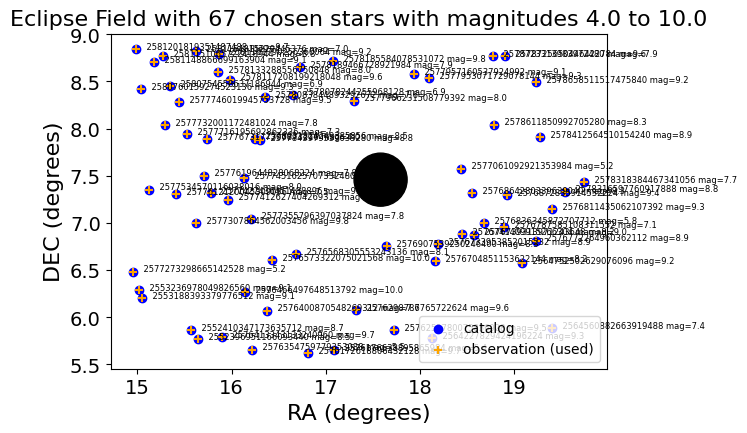

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.817414976981321
             x: [ 1.282e+00]
           nit: 26
          nfev: 52
 final_simplex: (array([[ 1.282e+00],
                       [ 1.282e+00]]), array([ 8.174e-01,  8.174e-01]))
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8174070052230955
             x: [ 1.413e+00  1.061e+00]
           nit: 102
          nfev: 193
 final_simplex: (array([[ 1.413e+00,  1.061e+00],
                       [ 1.413e+00,  1.061e+00],
                       [ 1.413e+00,  1.061e+00]]), array([ 8.174e-01,  8.174e-01,  8.174e-01]))
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8170585291298198
             x: [ 1.081e+00  6.343e-03]
           nit: 67
          nfev: 128
 final_simplex: (array([[ 1.081e+00,  6.343e-03],
                       [ 1.081e+00, 

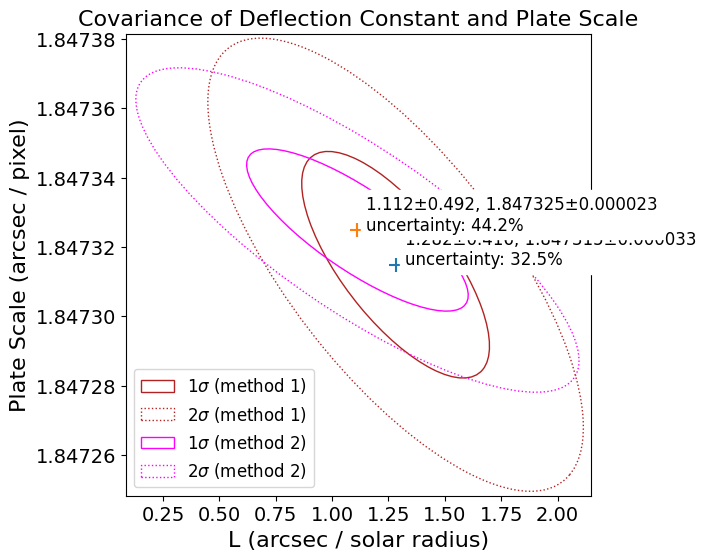

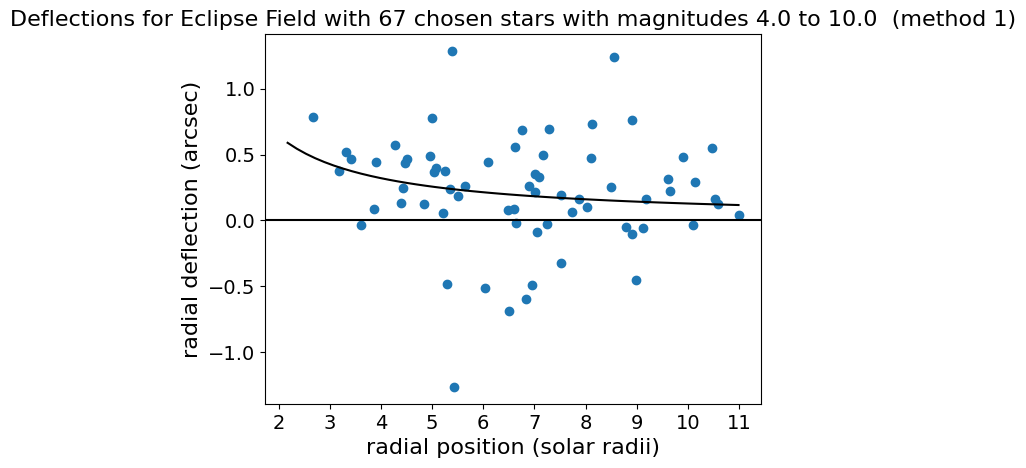

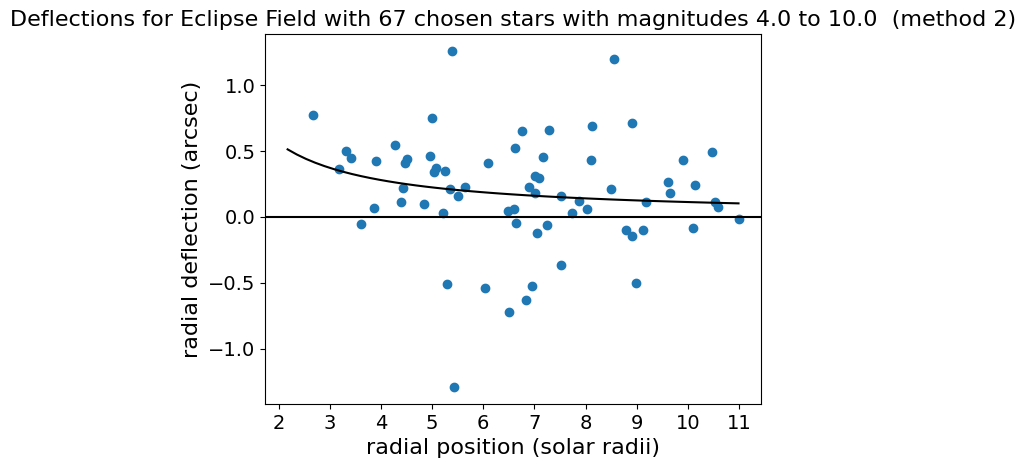

/Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3/ECLIPSE_OUTPUT20260619154543.txt

✅ SUCCESS! Eclipse analysis complete!

📁 Results in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3
   - ECLIPSE_OUTPUT{timestamp}.txt
   - ECLIPSE_OUTPUT{timestamp}/  (plots)

➡️  Run the Step 5 Results cell below to read L

   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 3/ECLIPSE_OUTPUT20260619154252.txt
   Pass check: #stars used=67, Method 1 L=1.282±0.416


In [18]:
# ============================================================================
# STEP 5: CALCULATE DEFLECTION COEFFICIENT
# ============================================================================
#
# PREREQUISITE: Run the Step 5 CONFIG cell above first.
# ============================================================================

import os

if "step5_options" not in globals() or "step5_distortion_zip_path" not in globals():
    raise RuntimeError("Run the Step 5 CONFIG cell above before this cell.")

step5_out = (
    globals().get("step5_output_directory")
    or step5_options.get("output_dir")
    or os.path.dirname(step5_distortion_zip_path)
)

print("=" * 60)
print("STEP 5: CALCULATING DEFLECTION COEFFICIENT")
print("=" * 60)
print()
print(f"Input file: {os.path.basename(step5_distortion_zip_path)}")
print(f"Output directory: {step5_out}")
print()
print("Expected result: L ≈ 1.751 arcseconds (Einstein's prediction)")
print()
print("Starting processing...")
print()

try:
    eclipse_analysis.eclipse_analysis(
        step5_distortion_zip_path,
        step5_options,
    )

    print()
    print("=" * 60)
    print("✅ SUCCESS! Eclipse analysis complete!")
    print("=" * 60)
    print()
    print(f"📁 Results in: {step5_out}")
    print("   - ECLIPSE_OUTPUT{timestamp}.txt")
    print("   - ECLIPSE_OUTPUT{timestamp}/  (plots)")
    print()
    print("➡️  Run the Step 5 Results cell below to read L")
    print()
    print("   Compare to: Final SD GUI Runs/06-19 Eclipse Tab 3/ECLIPSE_OUTPUT20260619154252.txt")
    print("   Pass check: #stars used=67, Method 1 L=1.282±0.416")

except Exception as e:
    print()
    print("=" * 60)
    print("❌ ERROR during eclipse analysis!")
    print("=" * 60)
    print(f"Error message: {e}")
    print()
    print("Common issues:")
    print("  - Step 4 zip invalid or from wrong run")
    print("  - Too few stars near the Sun after magnitude / radial cuts")
    print("  - Observer date/time in Step 4 distortion_results.txt incorrect")
    print()
    raise


### Step 5 Results

Finds `ECLIPSE_OUTPUT*.txt` under `step5_output_directory` and displays L.

In [19]:
# ============================================================================
# STEP 5 OUTPUT FILES
# ============================================================================

step5_out = (
    globals().get("step5_output_directory")
    or (step5_options.get("output_dir") if "step5_options" in globals() else None)
    or os.path.dirname(step5_distortion_zip_path)
)

if step5_out and os.path.isdir(step5_out):
    output_path = Path(step5_out)
else:
    output_path = Path(step5_distortion_zip_path).parent

print("=" * 60)
print("STEP 5 OUTPUT FILES")
print("=" * 60)
print()
print(f"Searching in: {output_path}")
print()

eclipse_outputs = sorted(
    output_path.glob("ECLIPSE_OUTPUT*.txt"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

output_dirs = sorted(
    [d for d in output_path.glob("ECLIPSE_OUTPUT*") if d.is_dir()],
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

if eclipse_outputs:
    latest_output = eclipse_outputs[0]
    print("✅ Found output files!")
    print()
    print(f"📄 Main results file: {latest_output.name}")
    print(f"   Full path: {latest_output}")
    print()

    step5_output_file = str(latest_output)
    print("💾 Saved as 'step5_output_file'")
    print()

    try:
        results_content = latest_output.read_text(encoding="utf-8")
        print("=" * 60)
        print("FINAL RESULTS")
        print("=" * 60)
        print()
        print(results_content)
    except Exception as e:
        print(f"⚠️  Could not read results file: {e}")

    if output_dirs:
        print()
        print(f"📁 Plots folder: {output_dirs[0].name}")

    print()
    print("=" * 60)
    print("✅ Step 5 Complete!")
    print("=" * 60)

else:
    print("⚠️  No ECLIPSE_OUTPUT*.txt found.")
    print(f"   Searched in: {output_path}")
    print("   Run the Step 5 processing cell above first.")


STEP 5 OUTPUT FILES

Searching in: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3

✅ Found output files!

📄 Main results file: ECLIPSE_OUTPUT20260619154543.txt
   Full path: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab3/ECLIPSE_OUTPUT20260619154543.txt

💾 Saved as 'step5_output_file'

FINAL RESULTS

MEE2024 version: v0.6.0
input file: /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/MEE2024_outputs/eclipse_tab2/distortion_data20260619153056__centroid_data2026061915052120260619150521.zip

limiting magnitude: 12.0
cutoff sun radii: Noneremove double stars: True
number of stars used: 67
deflection constant = 1.28163
difference vs. accepted value: -26.806%

deflected star position rms = 0.817 arcsec
rms / sqrt(nstars) = 0.09986 arcsec
naive uncertainty estimate = 5.7%
Method 1 results: L=1.282±0.416, platescale=1.847315±0.000033 arcsec, L uncertainty: 32.5%

Method 1 results: L=1.

---

# 🔧 Troubleshooting Guide

This section helps you diagnose and fix common issues that may arise during analysis.

---

## Common Issues and Solutions

### 1. File Not Found Errors

**Symptoms:**
- Error messages like `FileNotFoundError` or `No such file or directory`
- Files not being detected during validation

**Solutions:**
- ✅ **Check file paths are correct** - Use absolute paths (full path from root) for best results
- ✅ **Verify files exist** - Use file explorer to confirm files are where you think they are
- ✅ **Check file permissions** - Make sure files are readable (not locked by another program)
- ✅ **Use forward slashes** - On Windows, you can use `/` or `\\` in paths
- ✅ **Check for typos** - File names are case-sensitive on Mac/Linux

**Example of correct path format:**
```python
# Good (absolute path)
zenith_light_files = ['/Users/yourname/images/zenith_001.fits']

# Also good (relative to notebook location)
eclipse_light_files = ['./data/eclipse_001.fits']

# Bad (will fail)
eclipse_light_files = ['eclipse_001.fits']  # Missing path
```

---

### 2. Plate Solving Fails

**Symptoms:**
- Error: "Plate solving failed" or "No plate solution found"
- Step 1 completes but no plate solution in output

**Solutions:**
- ✅ **Check image quality** - Images need enough stars (at least 10-20 bright stars)
- ✅ **Verify images are not too dark or too bright** - Stars should be visible but not saturated
- ✅ **Check field of view** - Very wide or very narrow fields may be harder to solve
- ✅ **Ensure images overlap** - All images should show the same region of sky
- ✅ **Try different stacking options** - Adjust `sensitive_mode_stack` or `centroid_gaussian_subtract`
- ✅ **Check for Sun/Moon blocking stars** - If Sun/Moon is too large, may not have enough stars

**What to check:**
- Open your stacked image and verify you can see stars
- Count how many stars are visible (need at least 10-20)
- Check that images are properly aligned

---



### 3b. Eclipse stacking (Step 3)

**Symptoms:** Too few centroids, plate solve fails, Sun not masked.

**Solutions:**
- ✅ **`delete_saturated_blob`: True** in `TAB3_SETTINGS` (required for eclipse)
- ✅ Tune `blob_radius_extra`, `centroid_gap_blob` to match GUI Tab 1 eclipse run
- ✅ **Match file order** to GUI — first file in `eclipse_light_files` is the reference frame
- ✅ Outputs go to `MEE2024_outputs/eclipse_tab1/` — check `step3_output_file` after the results cell

---

### 3c. Eclipse distortion (Step 4)

**Symptoms:** Error about missing reference file, or wrong polynomial order.

**Solutions:**
- ✅ **`zenith_distortion_zip`** must be Step 2 output (zenith calibration), not eclipse
- ✅ **`distortion_fixed_coefficients`: `"linear"`** and **`distortionOrder`: `"quintic"`** (same order as zenith reference)
- ✅ Edit **`TAB4_SETTINGS`** to match GUI eclipse Tab 2
- ✅ Outputs in `MEE2024_outputs/eclipse_tab2/` → `step4_output_file` for Step 5

### 3. Distortion Fitting Fails (Steps 2 or 4)

**Symptoms:**
- Error: "Distortion fit failed" or "Not enough matched stars"
- Step 2 or 4 fails to create output file

**Solutions:**
- ✅ **Verify the preceding Find Centroids step completed** - Check that `centroid_data*.zip` exists
- ✅ **Check input ZIP file is valid** - Try opening it manually to verify it's not corrupted
- ✅ **Verify observation date is correct** - Wrong date will cause star positions to be off
- ✅ **Check internet connection** - Gaia queries require internet access
- ✅ **Ensure enough stars matched** - Need at least 10-20 stars matched to Gaia
- ✅ **Check star magnitude limits** - Adjust `max_star_mag_dist` if needed (try 11 or 12)
- ✅ **For Step 4:** Check that `distortion_reference_files` points to a valid Step 2 output

**What to check:**
- Open the centroid ZIP and verify it contains star data
- Check that observation date matches when images were taken
- Verify internet connection is working

---

### 4. Eclipse Analysis Gives Unexpected Results (Step 5)

**Symptoms:**
- Deflection coefficient L is very different from 1.751 arcseconds
- Large uncertainty in the measurement
- Error messages about Sun position

**Solutions:**
- ✅ **Verify Step 4 completed successfully** - Check that eclipse `distortion_data*.zip` exists
- ✅ **Check observation date and time are correct** - Critical for calculating Sun position
- ✅ **Verify observation location (lat/long)** - Needed for accurate Sun position calculation
- ✅ **Check that stars are near the Sun** - Need stars within ~10 solar radii for good measurement
- ✅ **Review all earlier steps** - Systematic errors in Steps 1-4 will affect Step 5 results
- ✅ **Check limiting magnitude** - May need to adjust `eclipse_limiting_mag` to include more/fewer stars

**What to check:**
- Verify date format: `YYYY-MM-DD` (e.g., `2024-04-08`)
- Verify time format: `HH:MM:SS` in UTC (e.g., `18:30:00`)
- Check latitude/longitude are in degrees (e.g., `40.7128` for New York)
- Review diagnostic plots in output directory

---

### 5. No Stars Matched to Gaia Catalog

**Symptoms:**
- Error: "No stars matched" or "Gaia query returned no results"
- Step 2 fails during Gaia matching phase

**Solutions:**
- ✅ **Check internet connection** - Gaia queries require active internet
- ✅ **Verify observation date is correct** - Wrong date means wrong star positions
- ✅ **Check field has bright enough stars** - Gaia catalog has magnitude limits
- ✅ **Adjust magnitude limits** - Try increasing `max_star_mag_dist` to 12 or 13
- ✅ **Verify plate solution from Step 1** - If plate solve was wrong, Gaia matching will fail
- ✅ **Check for firewall/proxy issues** - Some networks block astroquery connections

**What to check:**
- Test internet connection (try opening a webpage)
- Verify observation date matches image capture date
- Check that Step 1 plate solution looks reasonable

---

### 6. Database Initialization Takes Too Long

**Symptoms:**
- Database initialization hangs or takes >10 minutes
- "Initializing star catalog database..." message doesn't complete

**Solutions:**
- ✅ **Wait patiently** - First-time initialization can take 5-10 minutes (one-time setup)
- ✅ **Check disk space** - Database needs several hundred MB of free space
- ✅ **Restart kernel** - If truly stuck, restart Jupyter kernel and try again
- ✅ **Check for errors** - Look for error messages in the output

**Note:** Database initialization only happens once. After the first run, it should be much faster.

---

### 7. Import Errors

**Symptoms:**
- `ModuleNotFoundError: No module named 'mee2024'`
- Import errors for other packages

**Solutions:**
- ✅ **Activate virtual environment** - Make sure you're in the correct virtual environment
- ✅ **Install MEE2024 package** - Run `pip install -e .` from the MEE2024 directory
- ✅ **Install dependencies** - Run `pip install -r requirements.txt`
- ✅ **Check Python version** - Need Python 3.9 or higher
- ✅ **Restart kernel** - After installing packages, restart Jupyter kernel

**Installation commands:**
```bash
# Activate virtual environment
source mee2024_env/bin/activate  # On Mac/Linux
# or
mee2024_env\Scripts\activate  # On Windows

# Install MEE2024
cd /path/to/MEE2024_HussainKinder
pip install -e .

# Install dependencies
pip install -r requirements.txt
```

---

### 8. Memory Errors

**Symptoms:**
- `MemoryError` or "Out of memory" messages
- Notebook crashes when processing large images

**Solutions:**
- ✅ **Reduce number of images** - Process fewer images at once
- ✅ **Close other programs** - Free up system memory
- ✅ **Use smaller images** - If possible, use lower resolution images
- ✅ **Process in batches** - Run Step 1 multiple times with subsets of images

---

## Getting Help

If you're still having issues:

1. **Check error messages carefully** - They often contain clues about what went wrong
2. **Review the output files** - Check what was created (or not created) at each step
3. **Verify your data** - Make sure your images are valid FITS files with stars visible
4. **Check the original GUI** - Try running the same data through the GUI to compare
5. **Review documentation** - Check the original MEE2024 README and papers

---

## Testing Your Setup

Before running your real data, you can test that everything is working:

1. ✅ **Test imports** - Run the import cell and verify no errors
2. ✅ **Test database** - Database initialization should complete without errors
3. ✅ **Test file validation** - Try validating a small set of test images
4. ✅ **Check output directories** - Verify you can write to the output directory

---

---

# ✅ Run checklist

Use this checklist as you work through the notebook (same flow as the GUI).

---

## Pre-Run

- [ ] Virtual environment active, `mee2024` installed
- [ ] Setup / import cell run (Gaia database ready)
- [ ] Internet available for Steps 2 and 4

---

## Step 1 — Zenith centroids (GUI Tab 1)

- [ ] `zenith_light_files` paths and **order** set (reference frame = first file)
- [ ] `output_directory` → `MEE2024_outputs/zenith_calibration_tab1/`
- [ ] Config → Validate → Run → Results cells executed
- [ ] `step1_output_file` points to `centroid_data*.zip`

---

## Step 2 — Zenith distortion (GUI Tab 2)

- [ ] `zenith_centroid_zip` or `step1_output_file` set
- [ ] `distortion_fixed_coefficients` = `"None"` (full fit)
- [ ] `step2_output_directory` → `zenith_calibration_tab2/`
- [ ] `step2_output_file` saved (needed as **reference** for Step 4)

---

## Step 3 — Eclipse centroids (GUI Tab 1, eclipse)

- [ ] `eclipse_light_files` paths and **order** set (match GUI eclipse Tab 1)
- [ ] `TAB3_SETTINGS`: blob masking **on**
- [ ] `step3_output_directory` → `MEE2024_outputs/eclipse_tab1/`
- [ ] `step3_output_file` saved

---

## Step 4 — Eclipse distortion (GUI Tab 2, eclipse)

- [ ] `eclipse_centroid_zip` or `step3_output_file` set
- [ ] `zenith_distortion_zip` or `step2_output_file` set (zenith calibration zip)
- [ ] `distortion_fixed_coefficients` = `"linear"`
- [ ] `step4_output_directory` → `MEE2024_outputs/eclipse_tab2/`
- [ ] `step4_output_file` saved for Step 5

---

## Step 5 — Deflection L (GUI Tab 3)

- [ ] `eclipse_distortion_zip` or `step4_output_file` set
- [ ] `TAB5_SETTINGS` matches GUI Tab 3
- [ ] `step5_output_directory` → `MEE2024_outputs/eclipse_tab3/`
- [ ] `step5_output_file` / `ECLIPSE_OUTPUT*.txt` produced

---



---

## Note on validation

This notebook does not include separate automated validation test cells. After each step, compare outputs to the GUI (same settings and file order) or inspect the ZIP / `distortion_results.txt` / `ECLIPSE_OUTPUT*.txt` files directly.

---


---

# 🎉 Completion Summary

You've run the full 5-step MEE2024 notebook pipeline (GUI-equivalent workflow).

## What each step produced

| Step | Folder | Variable |
|------|--------|----------|
| 1 | `MEE2024_outputs/zenith_calibration_tab1/` | `step1_output_file` |
| 2 | `MEE2024_outputs/zenith_calibration_tab2/` | `step2_output_file` |
| 3 | `MEE2024_outputs/eclipse_tab1/` | `step3_output_file` |
| 4 | `MEE2024_outputs/eclipse_tab2/` | `step4_output_file` |
| 5 | `MEE2024_outputs/eclipse_tab3/` | `step5_output_file` |

## Next steps

- Compare key outputs with GUI runs on the same data (centroid counts, distortion RMS, final L).
- Keep `step2_output_file` — it is the zenith reference for any eclipse Tab 2 / Step 4 rerun.

**Note:** Optional eclipse-day calibration is not in this notebook.

---

**Thank you for using the MEE2024 Notebook Version!**

---


---

## 📋 Example workflow & output layout

### Recommended project layout

```
MEE2024_HussainKinder/
├── MEE 2024 Sample Data/
│   ├── calibration/          ← Step 1 zenith FITS
│   └── eclipse/              ← Step 3 eclipse FITS
├── MEE2024_outputs/
│   ├── zenith_calibration_tab1/   ← Step 1: centroid_data*.zip
│   ├── zenith_calibration_tab2/   ← Step 2: distortion_data*.zip (reference for Step 4)
│   ├── eclipse_tab1/              ← Step 3: centroid_data*.zip
│   ├── eclipse_tab2/              ← Step 4: distortion_data*.zip
│   └── eclipse_tab3/              ← Step 5: ECLIPSE_OUTPUT*.txt + plots
└── MEE2024_Notebook_Version.ipynb
```

### Configuration pattern (each step)

| Step | Edit in config cell | Run with |
|------|---------------------|----------|
| 1 | `zenith_*_files`, `TAB1_SETTINGS`, `output_directory` | `options` |
| 2 | `zenith_centroid_zip`, `TAB2_SETTINGS`, `step2_output_directory` | `options` |
| 3 | `eclipse_*_files`, `TAB3_SETTINGS`, `step3_output_directory` | `step3_options` |
| 4 | `eclipse_centroid_zip`, `zenith_distortion_zip`, `TAB4_SETTINGS` | `step4_options` |
| 5 | `eclipse_distortion_zip`, `TAB5_SETTINGS`, `step5_output_directory` | `step5_options` |

### Example paths (edit to your machine)

```python
# Step 1 — see Step 1 config cell for full zenith file lists
output_directory = ".../MEE2024_outputs/zenith_calibration_tab1"

# Step 2
zenith_centroid_zip = ".../zenith_calibration_tab1/centroid_dataXXXXXXXX.zip"
step2_output_directory = ".../MEE2024_outputs/zenith_calibration_tab2"

# Step 3 — see Step 3 config cell for eclipse file lists (order matters)
step3_output_directory = ".../MEE2024_outputs/eclipse_tab1"

# Step 4
eclipse_centroid_zip = ""  # or step3_output_file after Step 3 results
zenith_distortion_zip = ".../zenith_calibration_tab2/distortion_dataXXXXXXXX.zip"
step4_output_directory = ".../MEE2024_outputs/eclipse_tab2"
```

### Outputs at each step

| Step | Main file | Contents |
|------|-----------|----------|
| 1 | `centroid_data*.zip` | Centroids, plate solution, stack |
| 2 | `distortion_data*.zip` | Full distortion coeffs, Gaia match table |
| 3 | `centroid_data*.zip` | Eclipse centroids + plate solution |
| 4 | `distortion_data*.zip` | Eclipse match table, linear refit + frozen zenith high-order |
| 5 | `ECLIPSE_OUTPUT*.txt` | Deflection constant L, diagnostics |

### Typical runtime

| Step | Time | Notes |
|------|------|-------|
| 1 | 5–15 min | Image count |
| 2 | 10–30 min | Gaia download |
| 3 | 5–15 min | Blob masking / fewer stars OK |
| 4 | 10–30 min | Needs Step 2 reference zip |
| 5 | 1–5 min | Uses Step 4 zip |

---

# Step 5
eclipse_distortion_zip = ""  # or step4_output_file
step5_output_directory = ".../MEE2024_outputs/eclipse_tab3"
